In [1]:
import numpy as np
import scipy.stats as stats
from scipy.stats import genpareto
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
from tqdm import tqdm_notebook, tnrange
stock_data = pd.read_excel('600900.SH.xlsx')
stock_data['logreturn'] = np.log(stock_data['收盘价(元)']/stock_data['收盘价(元)'].shift(1))
stock_data.dropna(inplace=True)

# Mean Excess Plot

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34632\425362971.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for threshold in tqdm_notebook(thresholds):


  0%|          | 0/1747 [00:00<?, ?it/s]

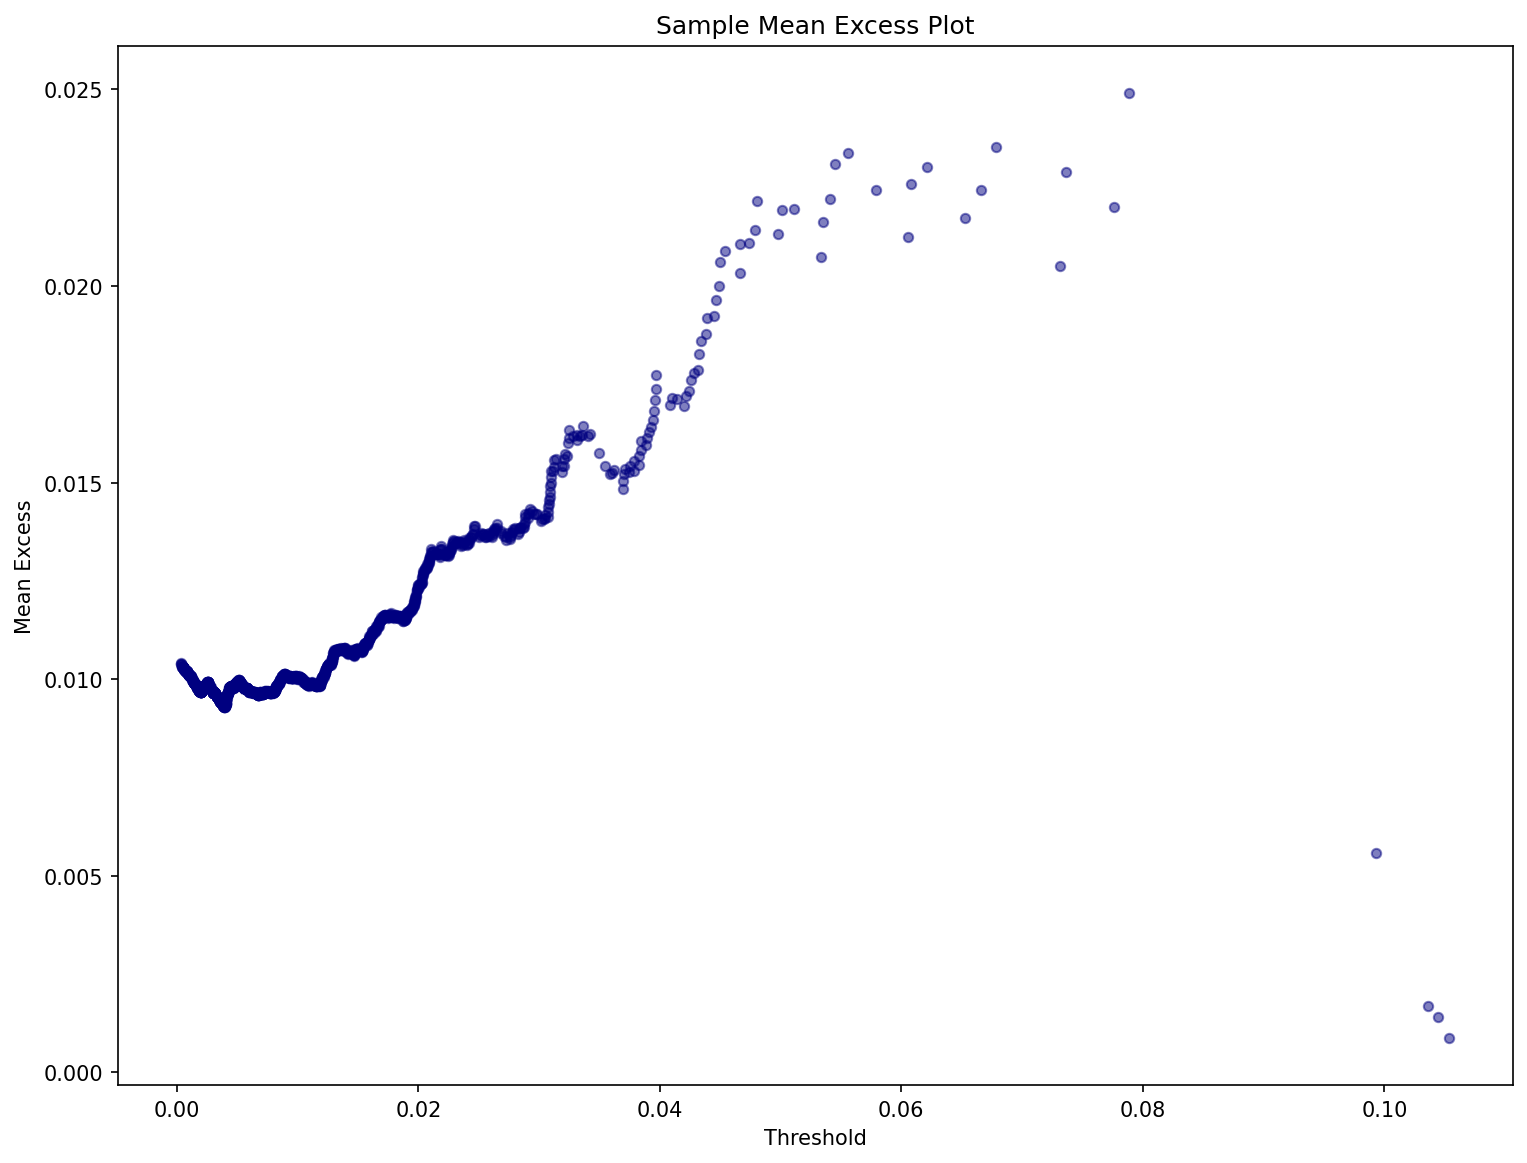

In [3]:
logreturn = stock_data[['logreturn', '日期']].set_index('日期')
loss = - logreturn['logreturn']

def plot_figB(loss):
    loss = loss[loss > 0]
    thresholds = loss.unique()
    mean_excesses = []
    Xs = []
    for threshold in tqdm_notebook(thresholds):
        exceedances = loss[loss > threshold] - threshold
        exceedances = exceedances[~np.isnan(exceedances)]
        if len(exceedances) > 0:
            mean_excesses.append(np.mean(exceedances))
            Xs.append(threshold)
    plt.figure(figsize=(12, 9), dpi=150)
    plt.scatter(Xs, mean_excesses, color='navy', s=20, alpha=0.5)
    plt.ylabel('Mean Excess')
    plt.xlabel('Threshold')
    plt.title('Sample Mean Excess Plot')
    plt.show()

plot_figB(loss)

# Empirical vs CDF

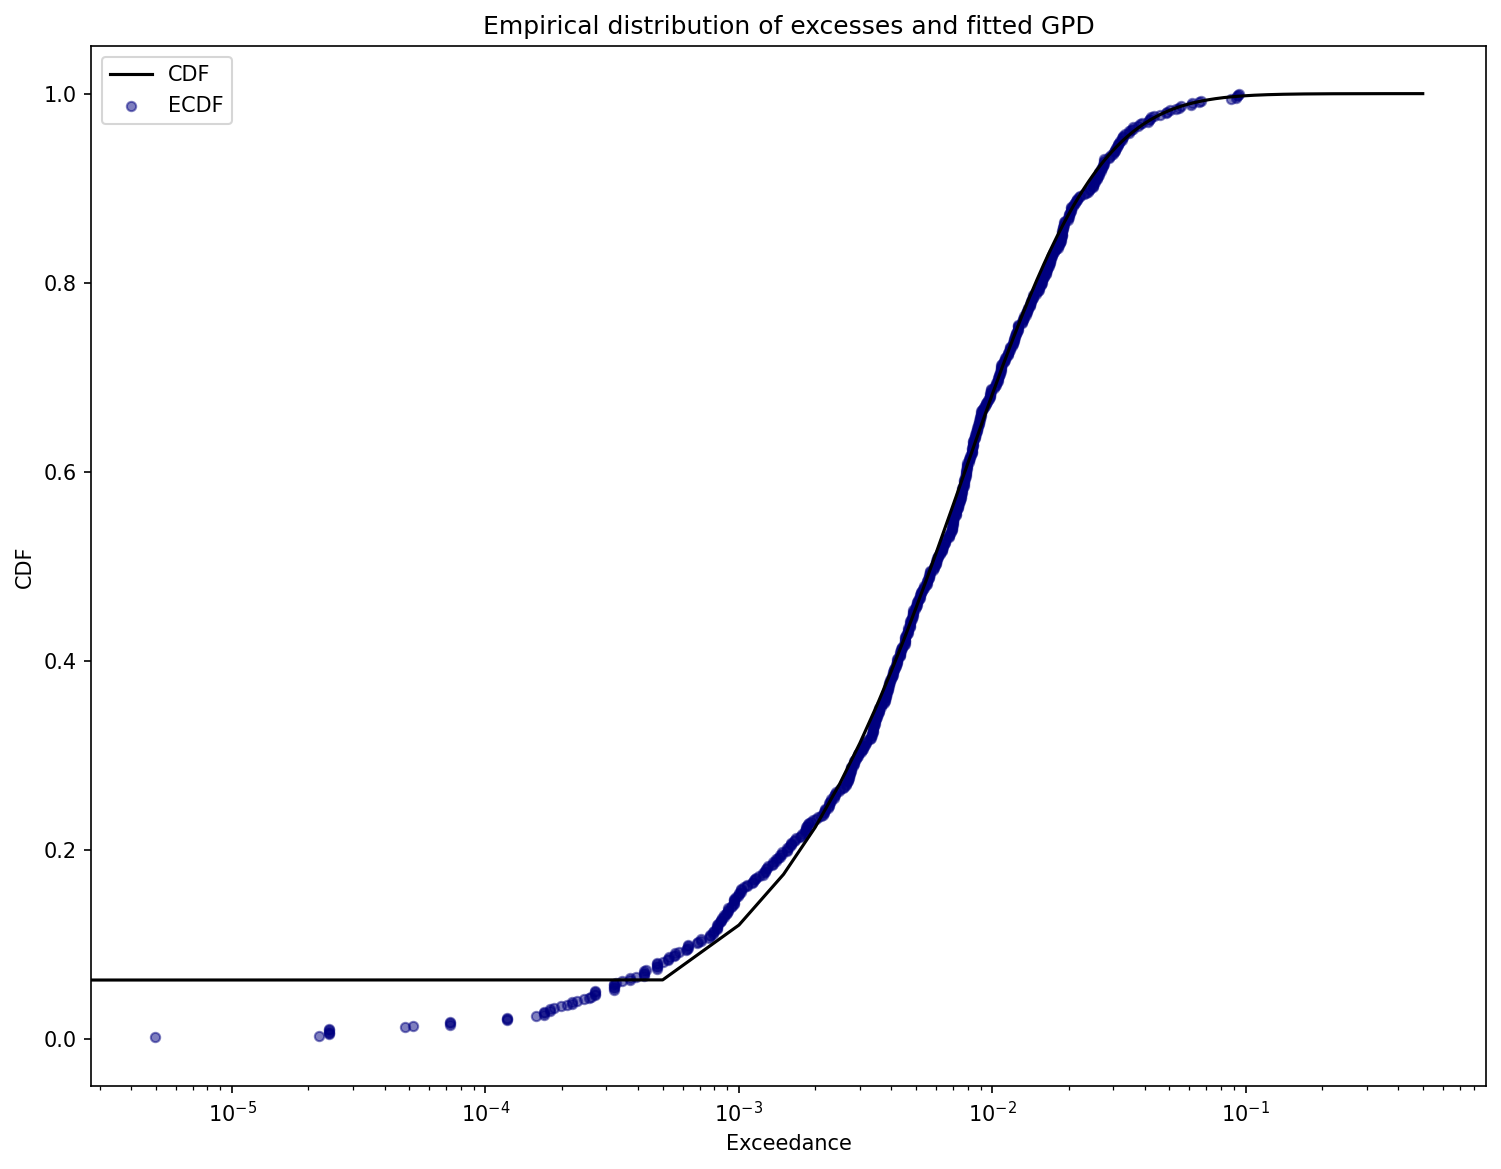

c: 0.22251301951511715
loc: 4.946031999628334e-06
scale: 0.007667296980898671
Num: 675


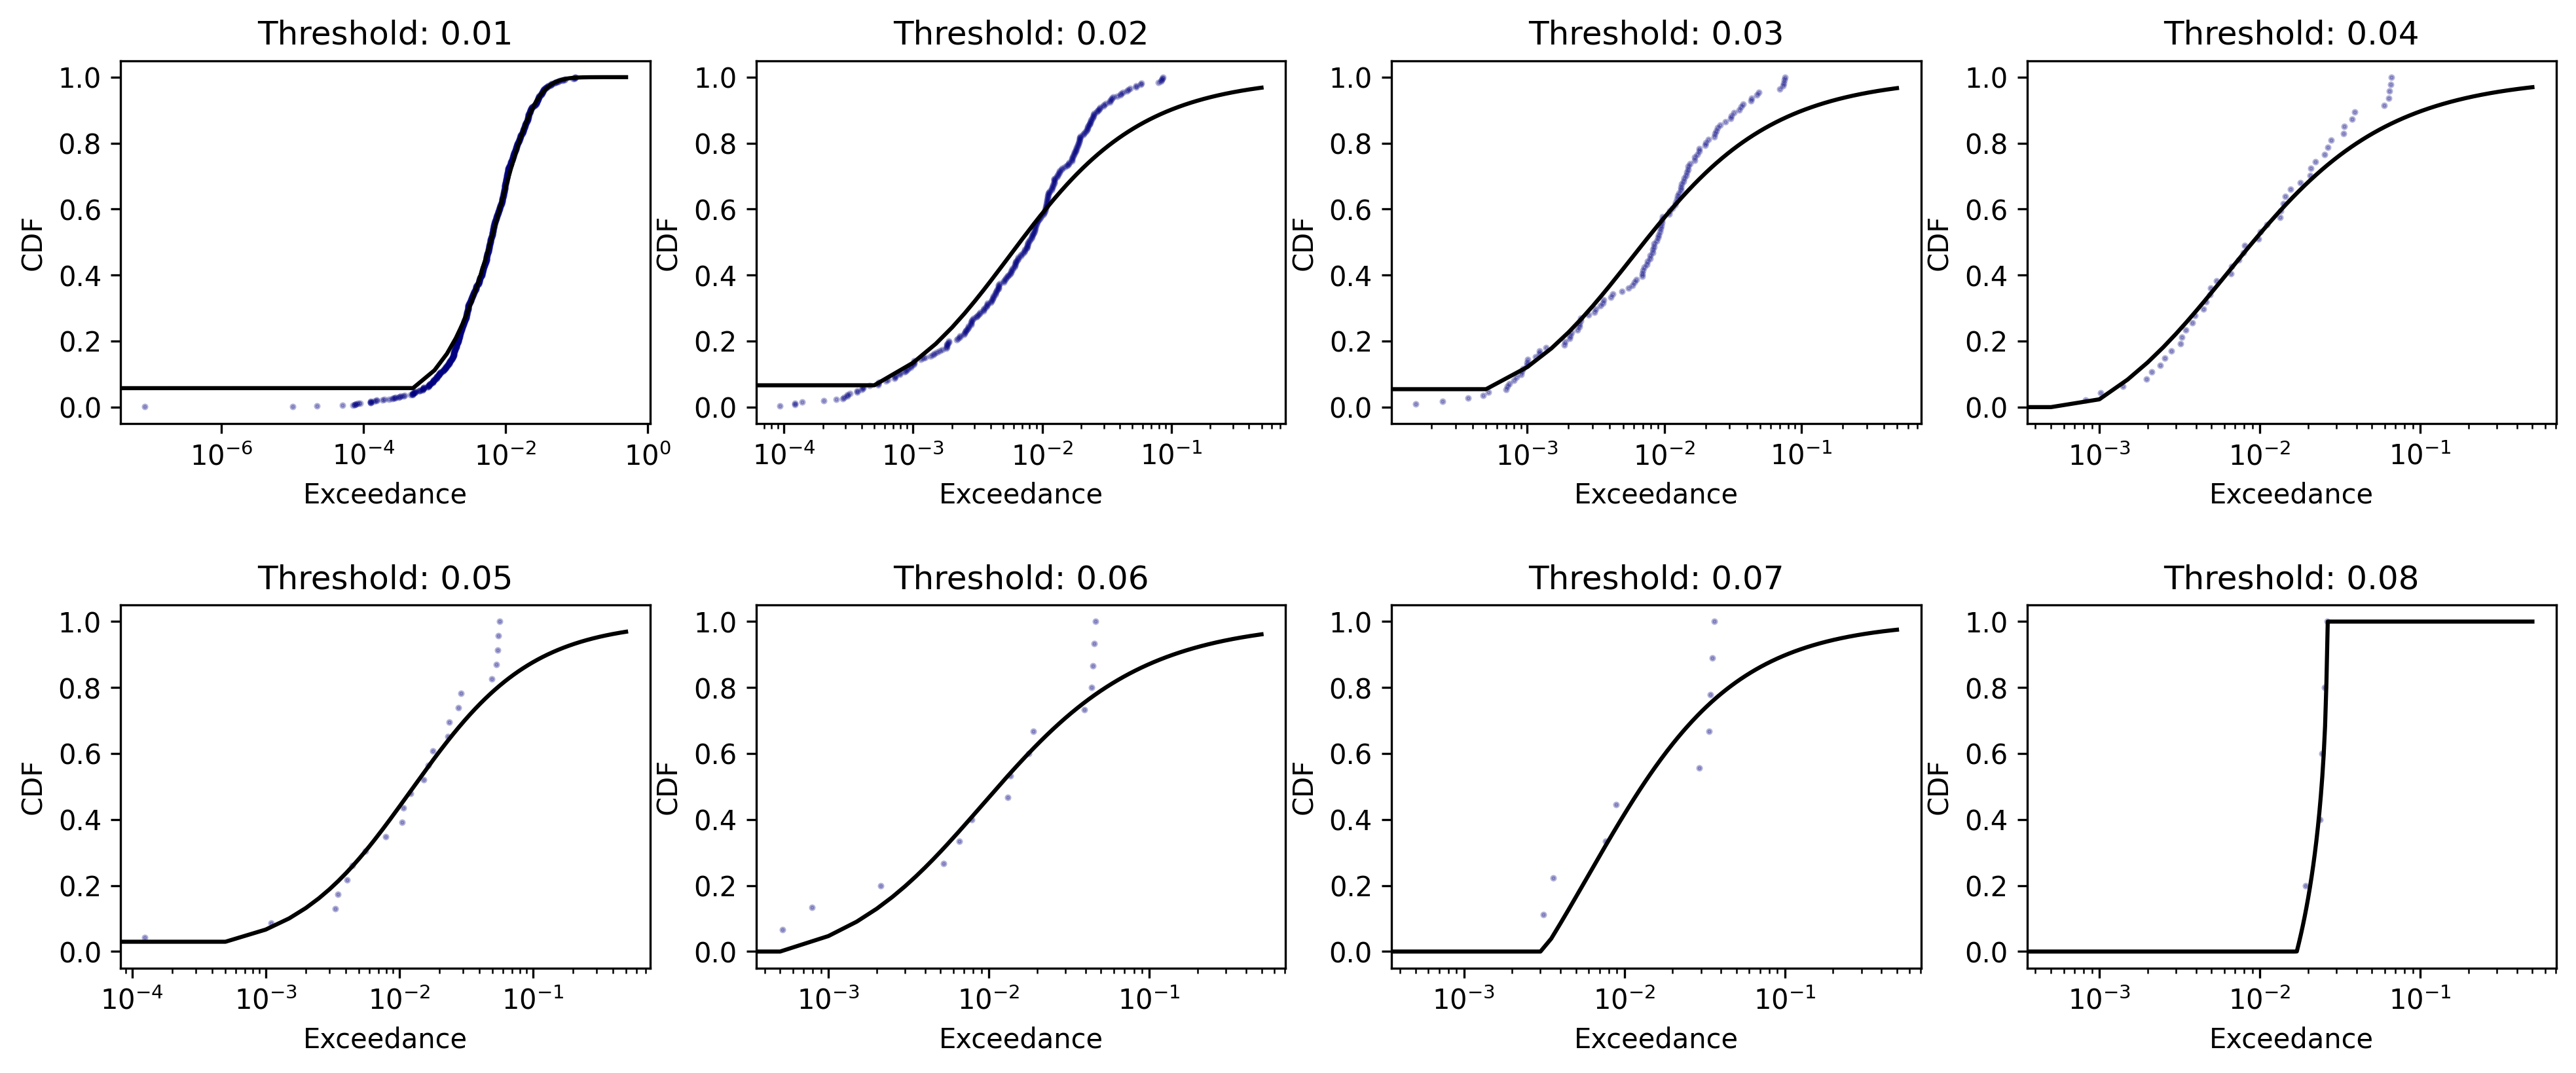

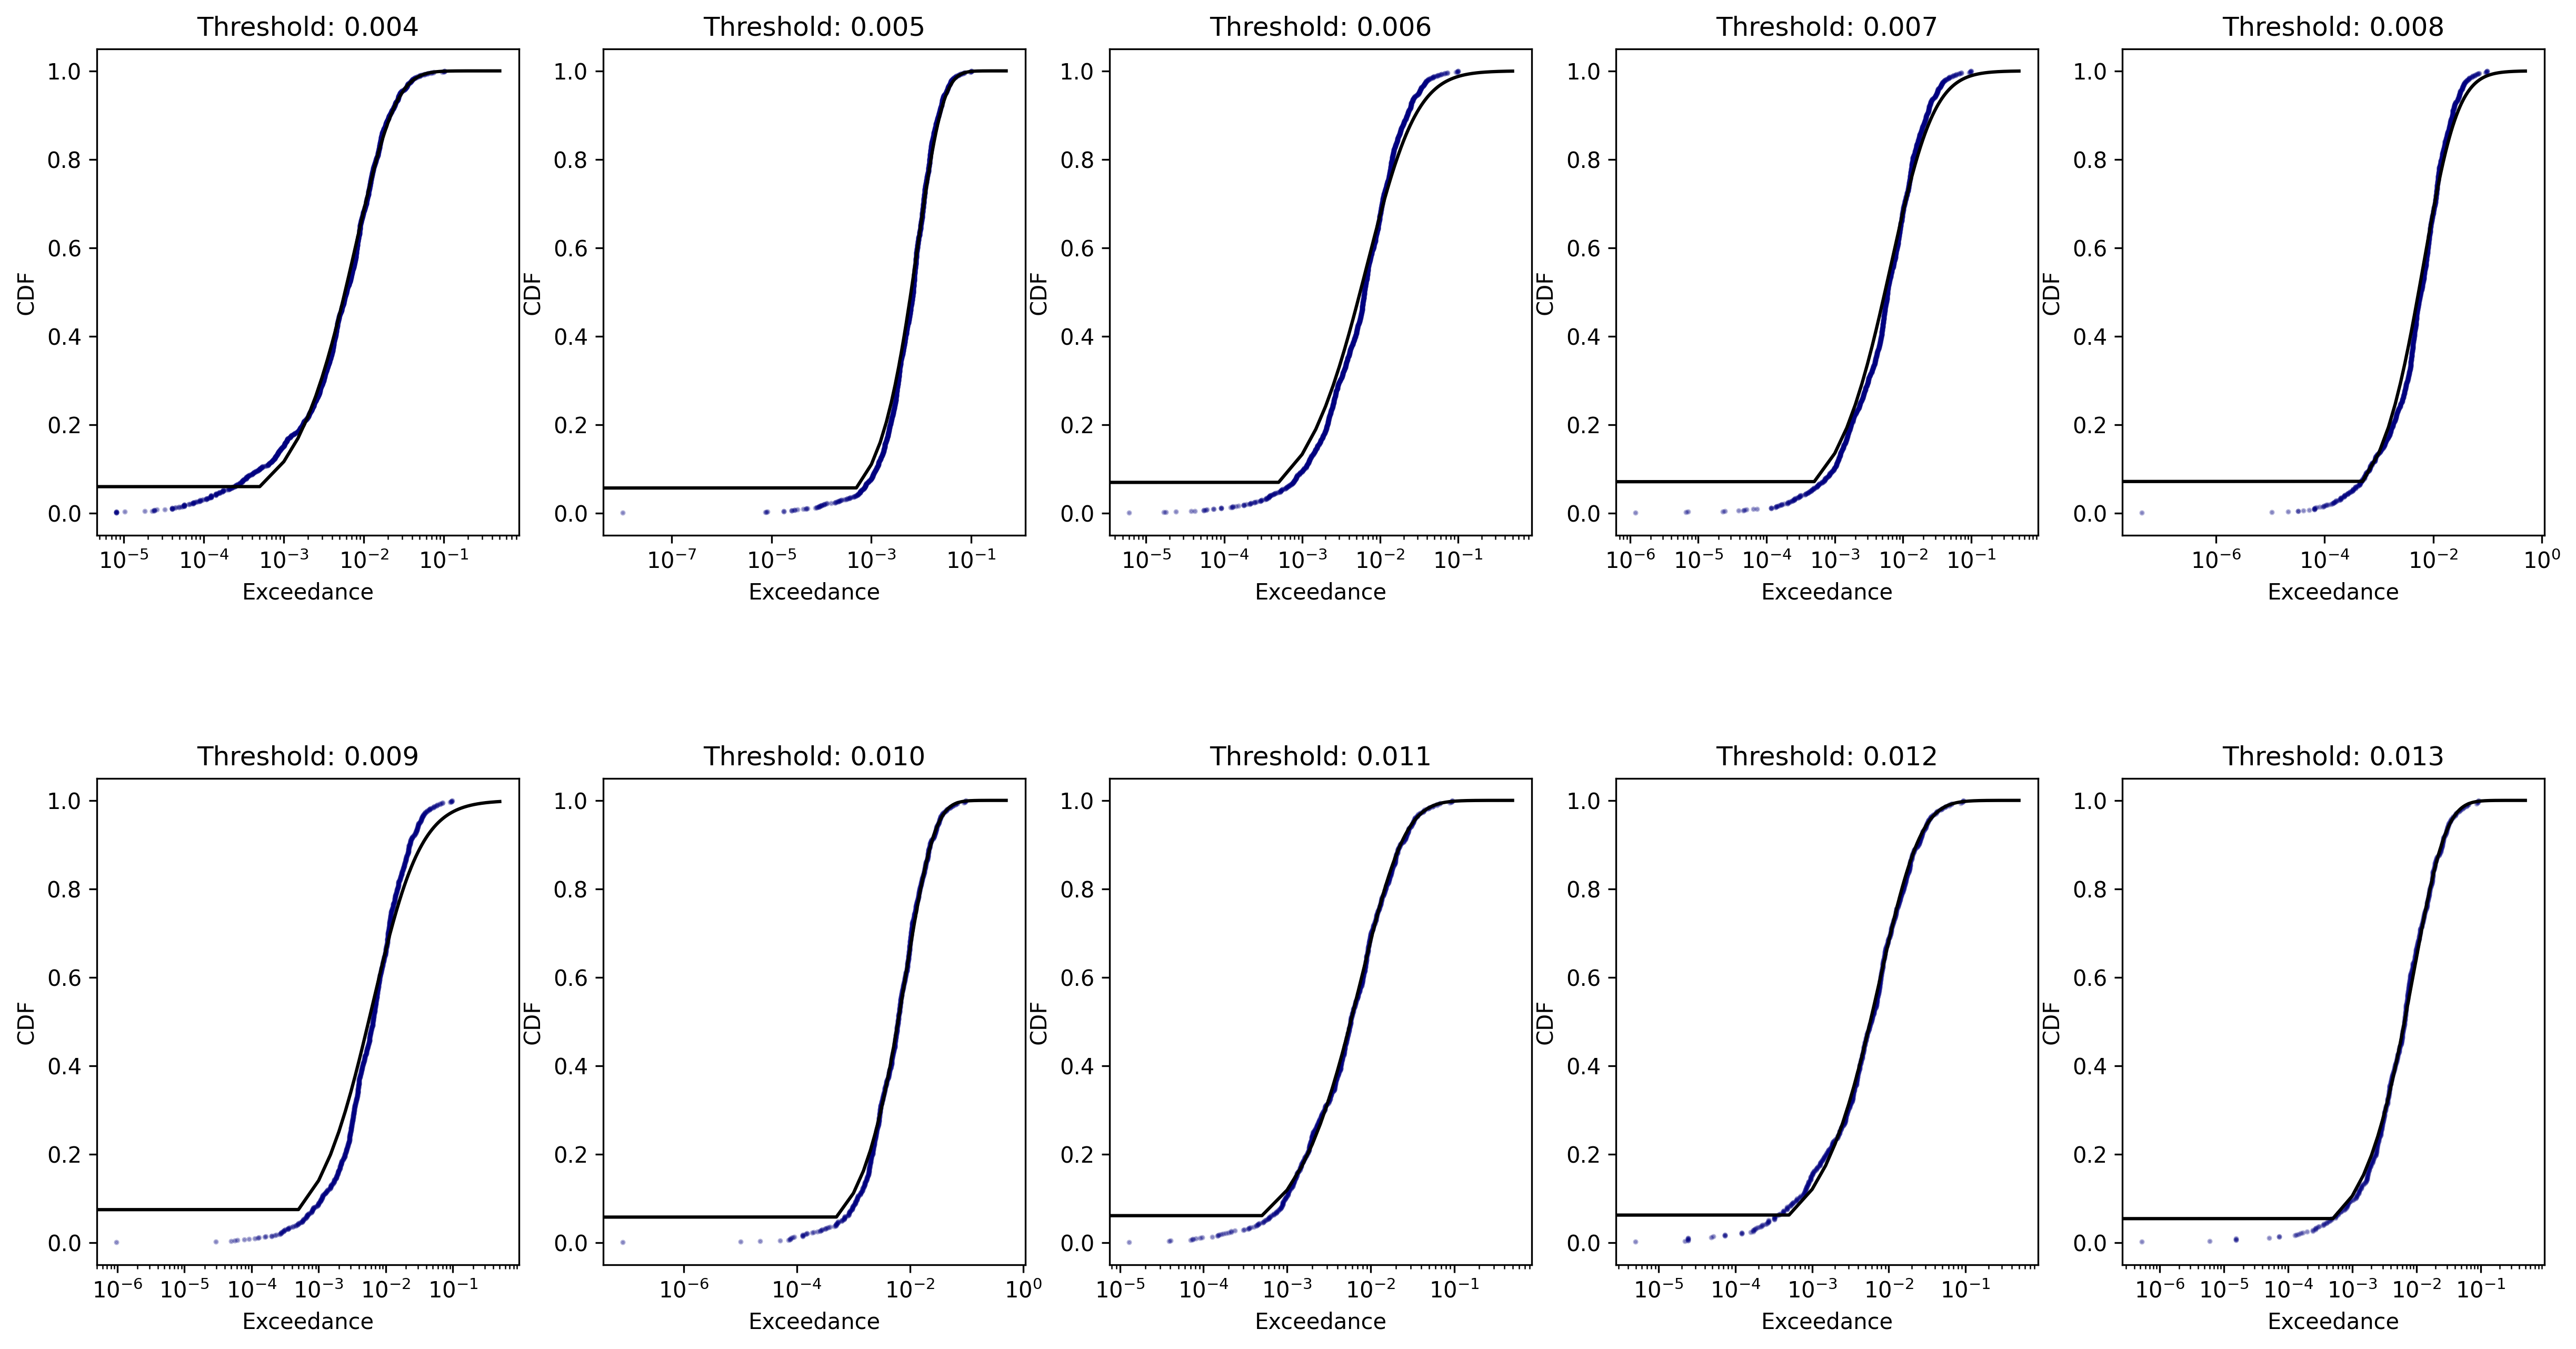

In [ ]:
def plot_figC(loss, threshold):
    exceedances = loss[loss > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    plt.figure(figsize=(12, 9), dpi=150)
    # cumulative distribution function
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    plt.plot(x, y, label='CDF', color='black')
    # empirical cumulative distribution function
    ecdf = ECDF(exceedances)
    # log scale X axis
    plt.xscale('log')
    plt.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.5, label='ECDF', color='navy', s=20)
    plt.ylabel('CDF')
    plt.xlabel('Exceedance')
    plt.title('Empirical distribution of excesses and fitted GPD')
    plt.legend()    
    plt.show()
    print('c:', c)
    print('loc:', loc)
    print('scale:', scale)
    print(f'Num: {len(exceedances)}')
plot_figC(loss, 0.012)

# subplots for thresholds from 0.01 to 0.08
fig, axs = plt.subplots(2, 4, figsize=(16, 6), dpi=300)
# log scale X axis
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.08, 8), axs.flatten()):
    exceedances = loss[loss > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.2f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

fig, axs = plt.subplots(2, 5, figsize=(20, 10), dpi=300)
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.004, 0.013, 10), axs.flatten()):
    exceedances = loss[loss > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.3f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

Hill_loss:, 0.0456


C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\1052112952.py:14: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\1052112952.py:5: RuntimeWarning: divide by zero encountered in divide
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\1052112952.py:5: RuntimeWarning: invalid value encountered in divide
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\1052112952.py:5: RuntimeWarning: invalid value encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\1052112952.py:5: RuntimeWarning: divide by zero encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))


Text(0.5, 1.0, 'Hill Estimator of Alpha')

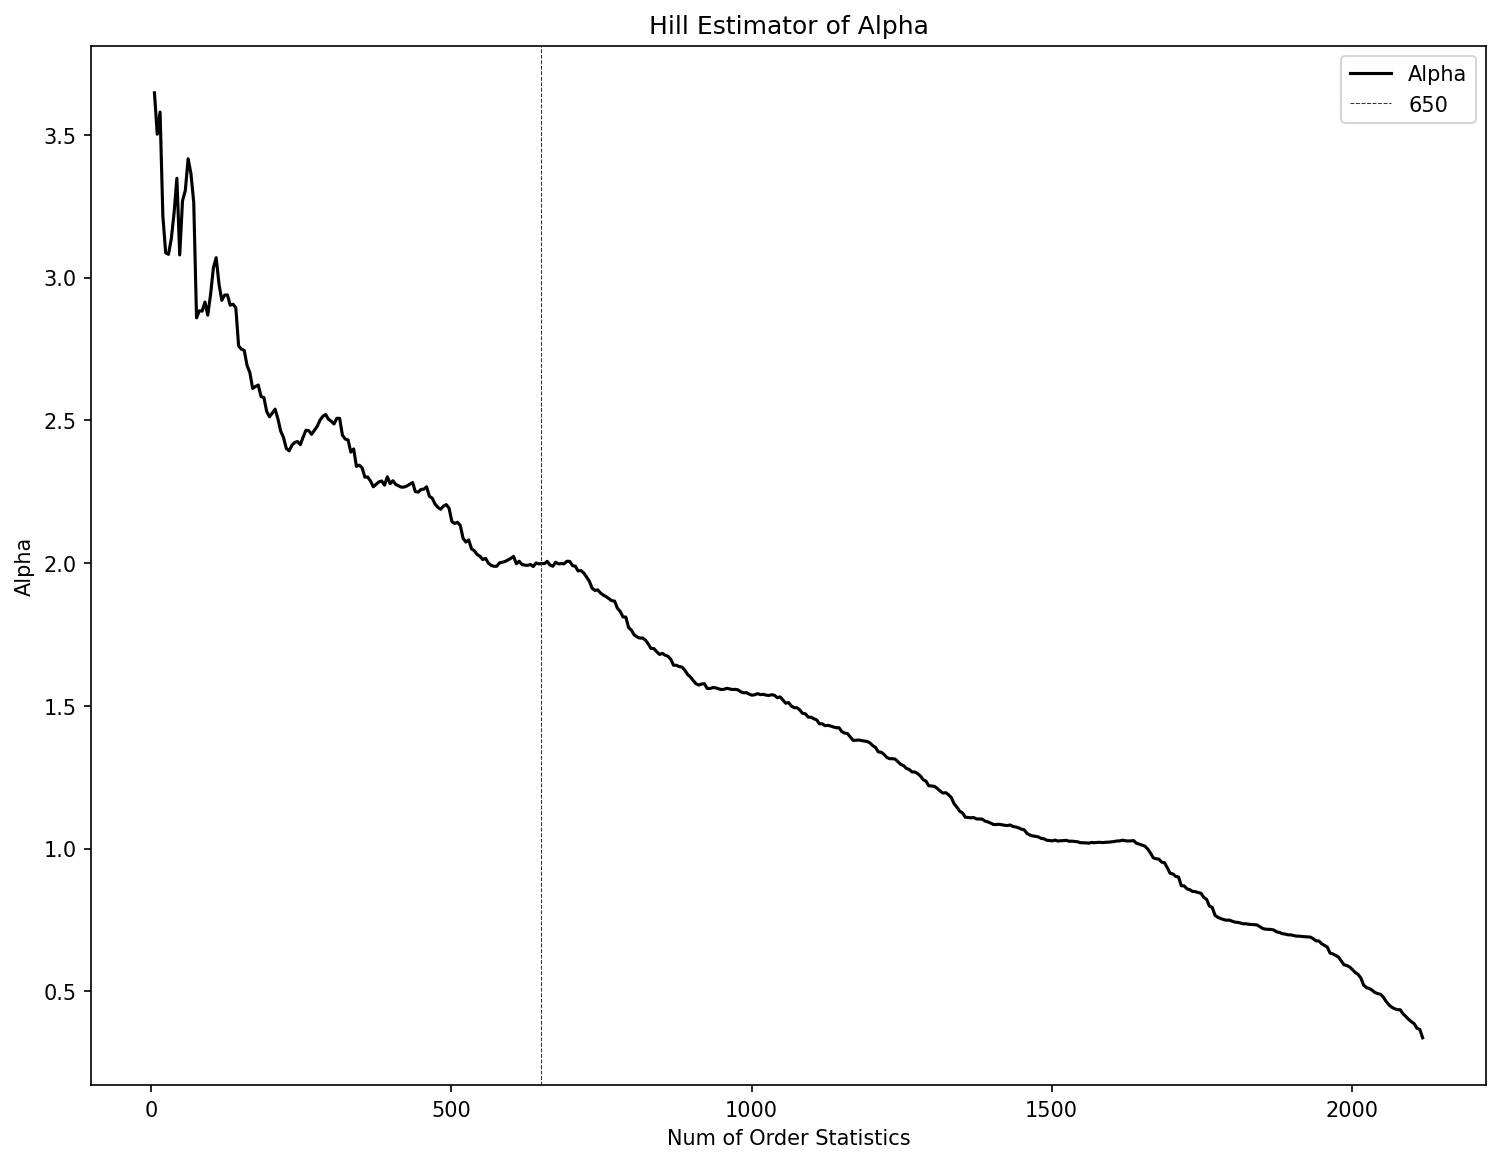

In [102]:
def q_hill(data, quantile=0.99, k=500):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]
    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha

print(f'Hill_loss:, {q_hill(loss, k=650)[0]:.4f}')
alphas = []
ks = np.linspace(5, 4676, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(loss, quantile=0.99, k=int(k))
    alphas.append(alpha)

plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')

plt.axvline(650, color='purple', linestyle='--', label='650', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\742568271.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Hill Estimator of Alpha')

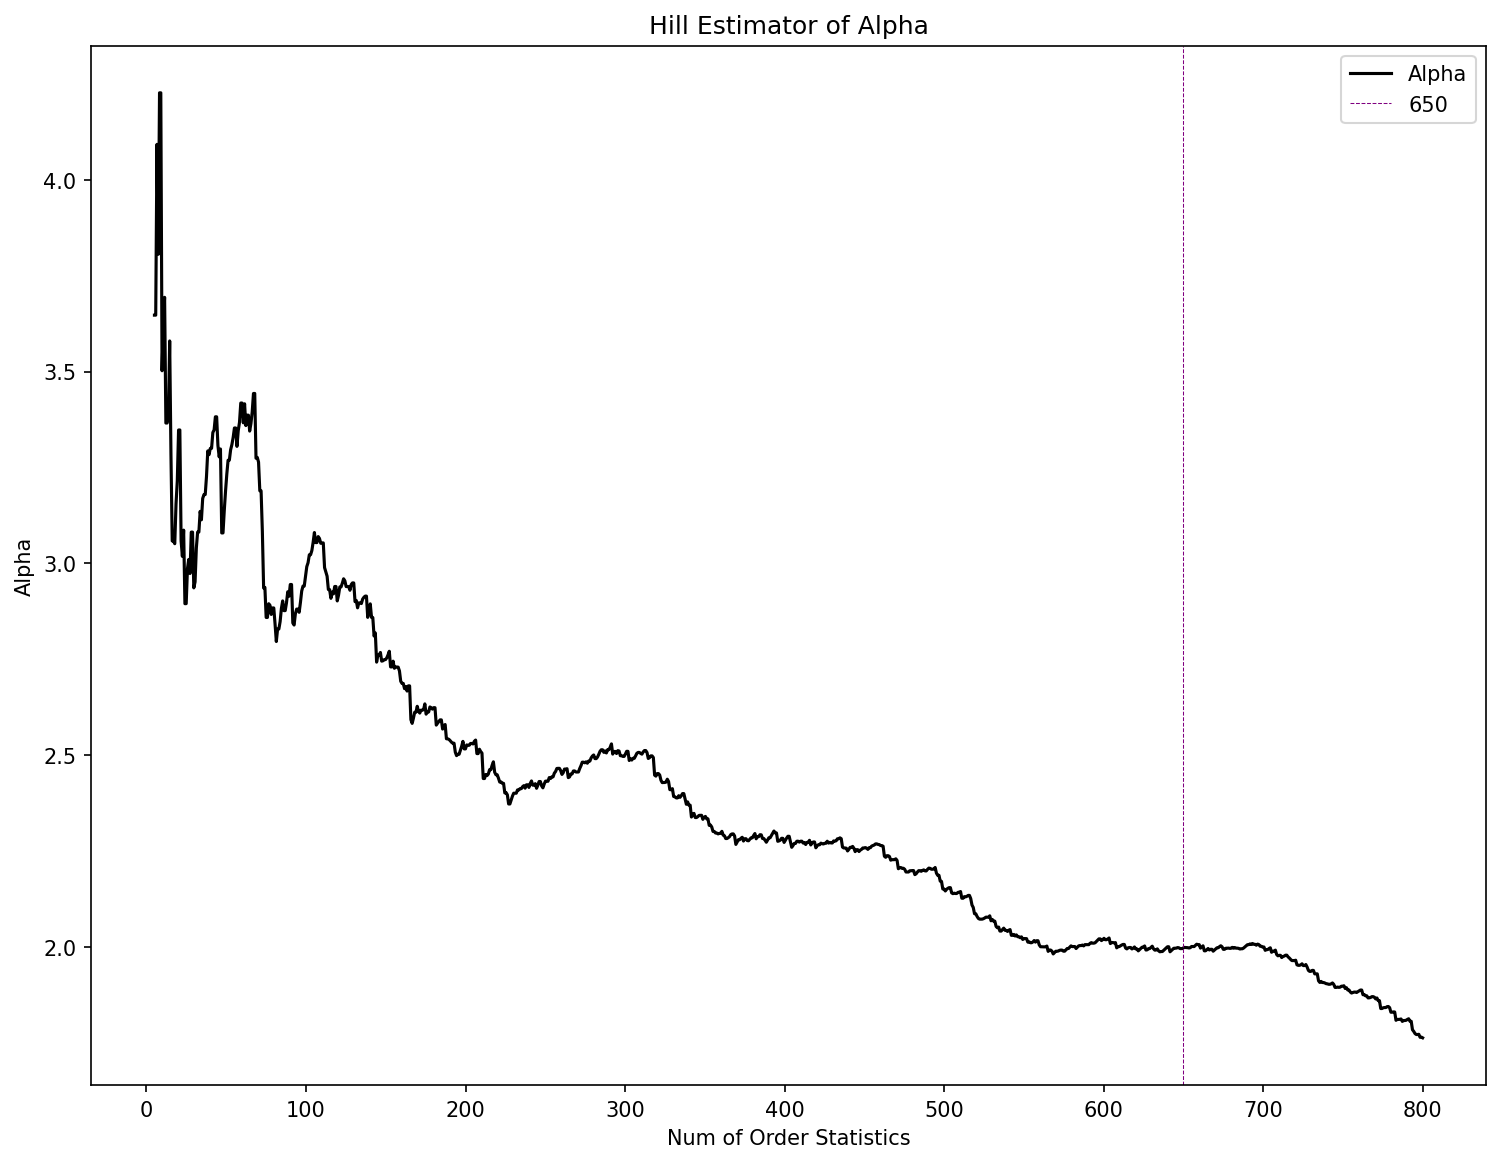

In [83]:
alphas = []
ks = np.linspace(5, 800, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha= q_hill(loss, quantile=0.99, k=int(k))
    alphas.append(alpha)

plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')
plt.axvline(650, color='purple', linestyle='--', label='650', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

Gaussian_loss: 0.0349
Empirical_loss: 0.0400


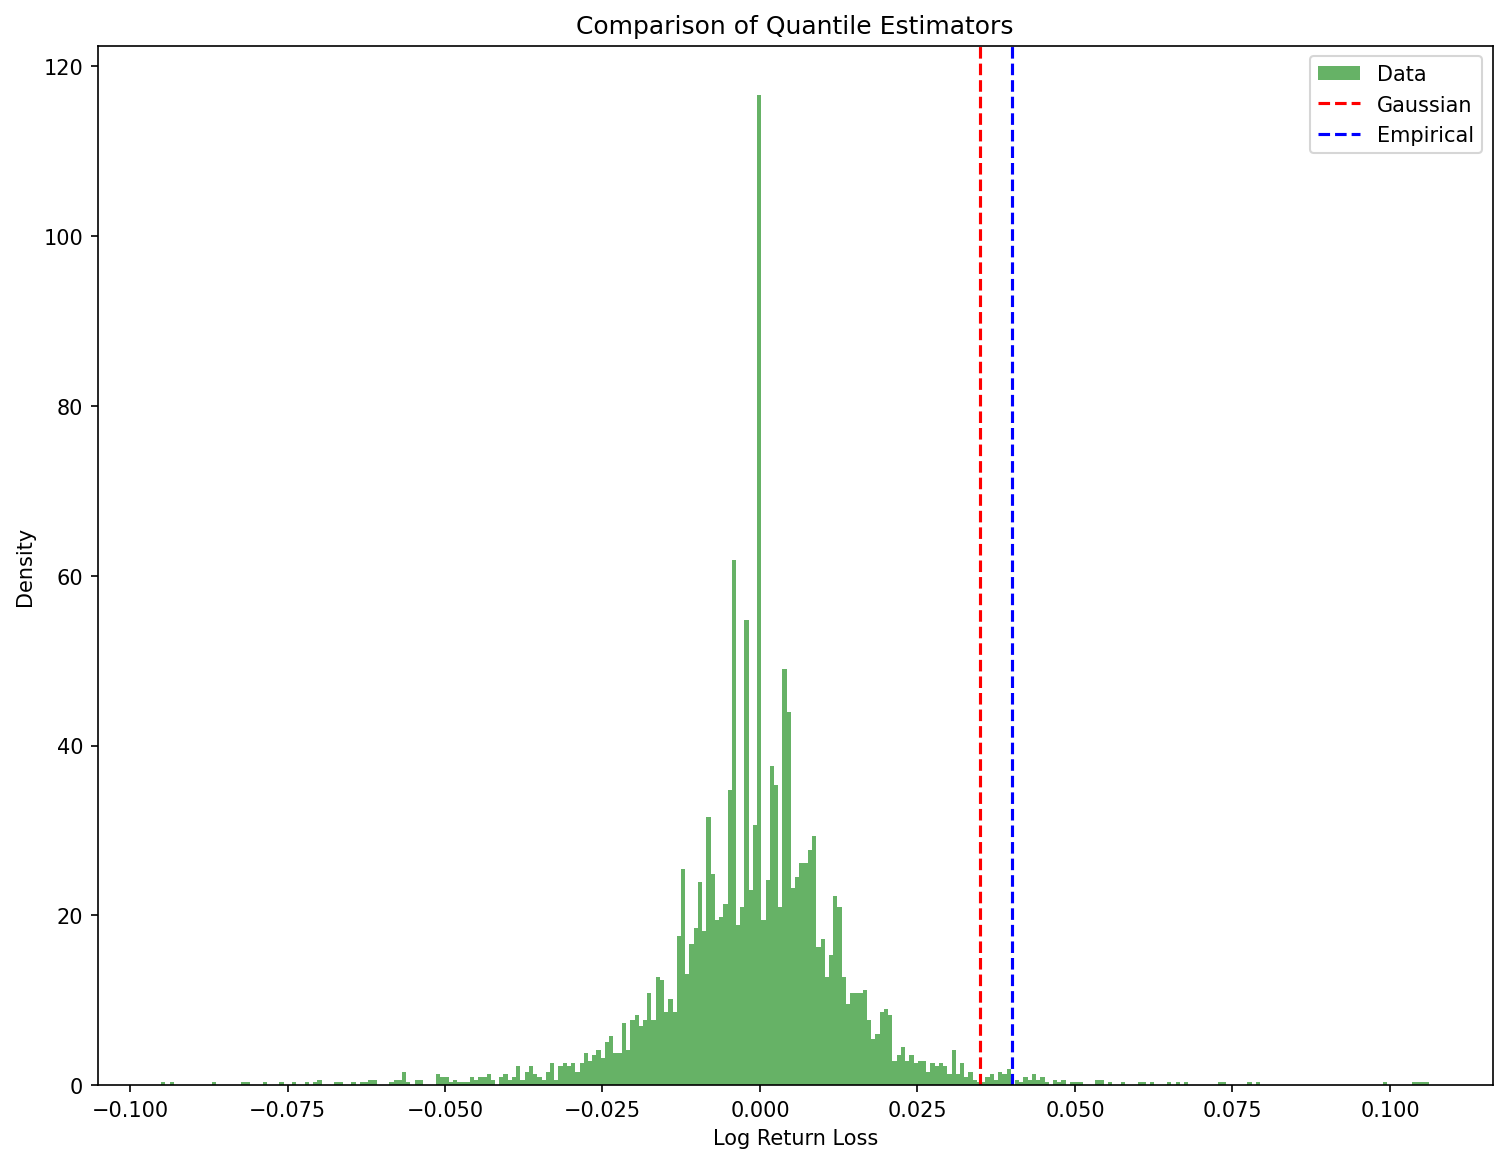

In [130]:
def q_gaussian(data, alpha=0.99):
    mean = np.mean(data)
    std = np.std(data)
    return stats.norm.ppf(alpha, loc=mean, scale=std)


def q_empirical(data, alpha=0.99):
    return np.quantile(data, alpha)

print(f'Gaussian_loss: {q_gaussian(loss):.4f}')
print(f'Empirical_loss: {q_empirical(loss):.4f}')
data = loss
plt.figure(figsize=(12, 9), dpi=150)
plt.hist(data, bins=300, density=True, alpha=0.6, color='g', label='Data')
plt.axvline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axvline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.legend()
plt.title("Comparison of Quantile Estimators")
plt.xlabel('Log Return Loss')
plt.ylabel('Density')
plt.show()

Gaussian_loss: 0.0349
Empirical_loss: 0.0400
POT_loss: 0.0400
Hill_loss: 0.0456


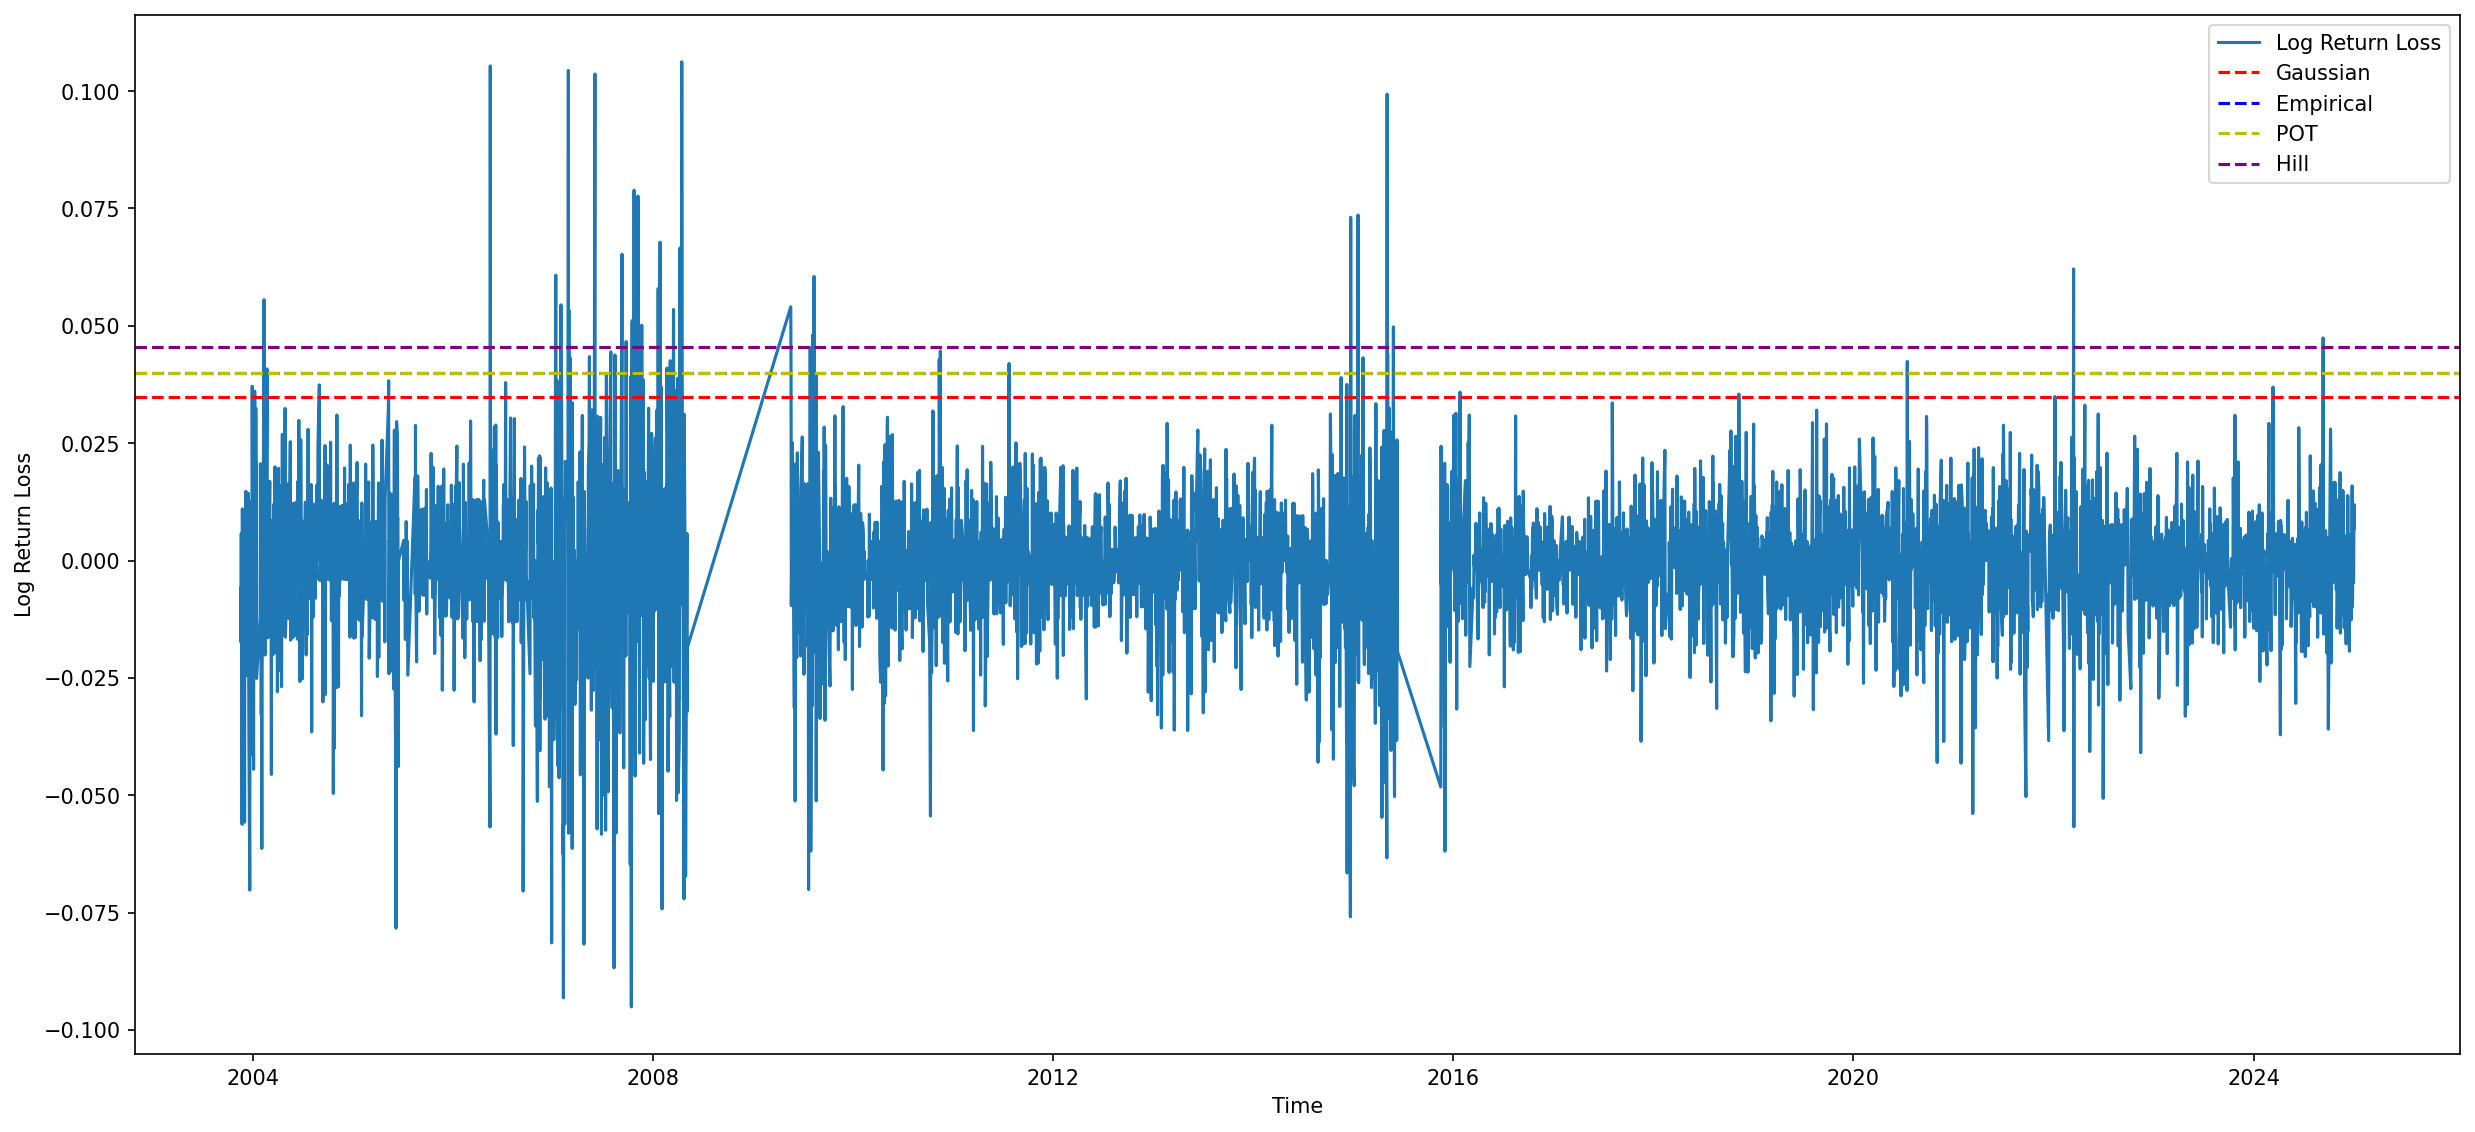

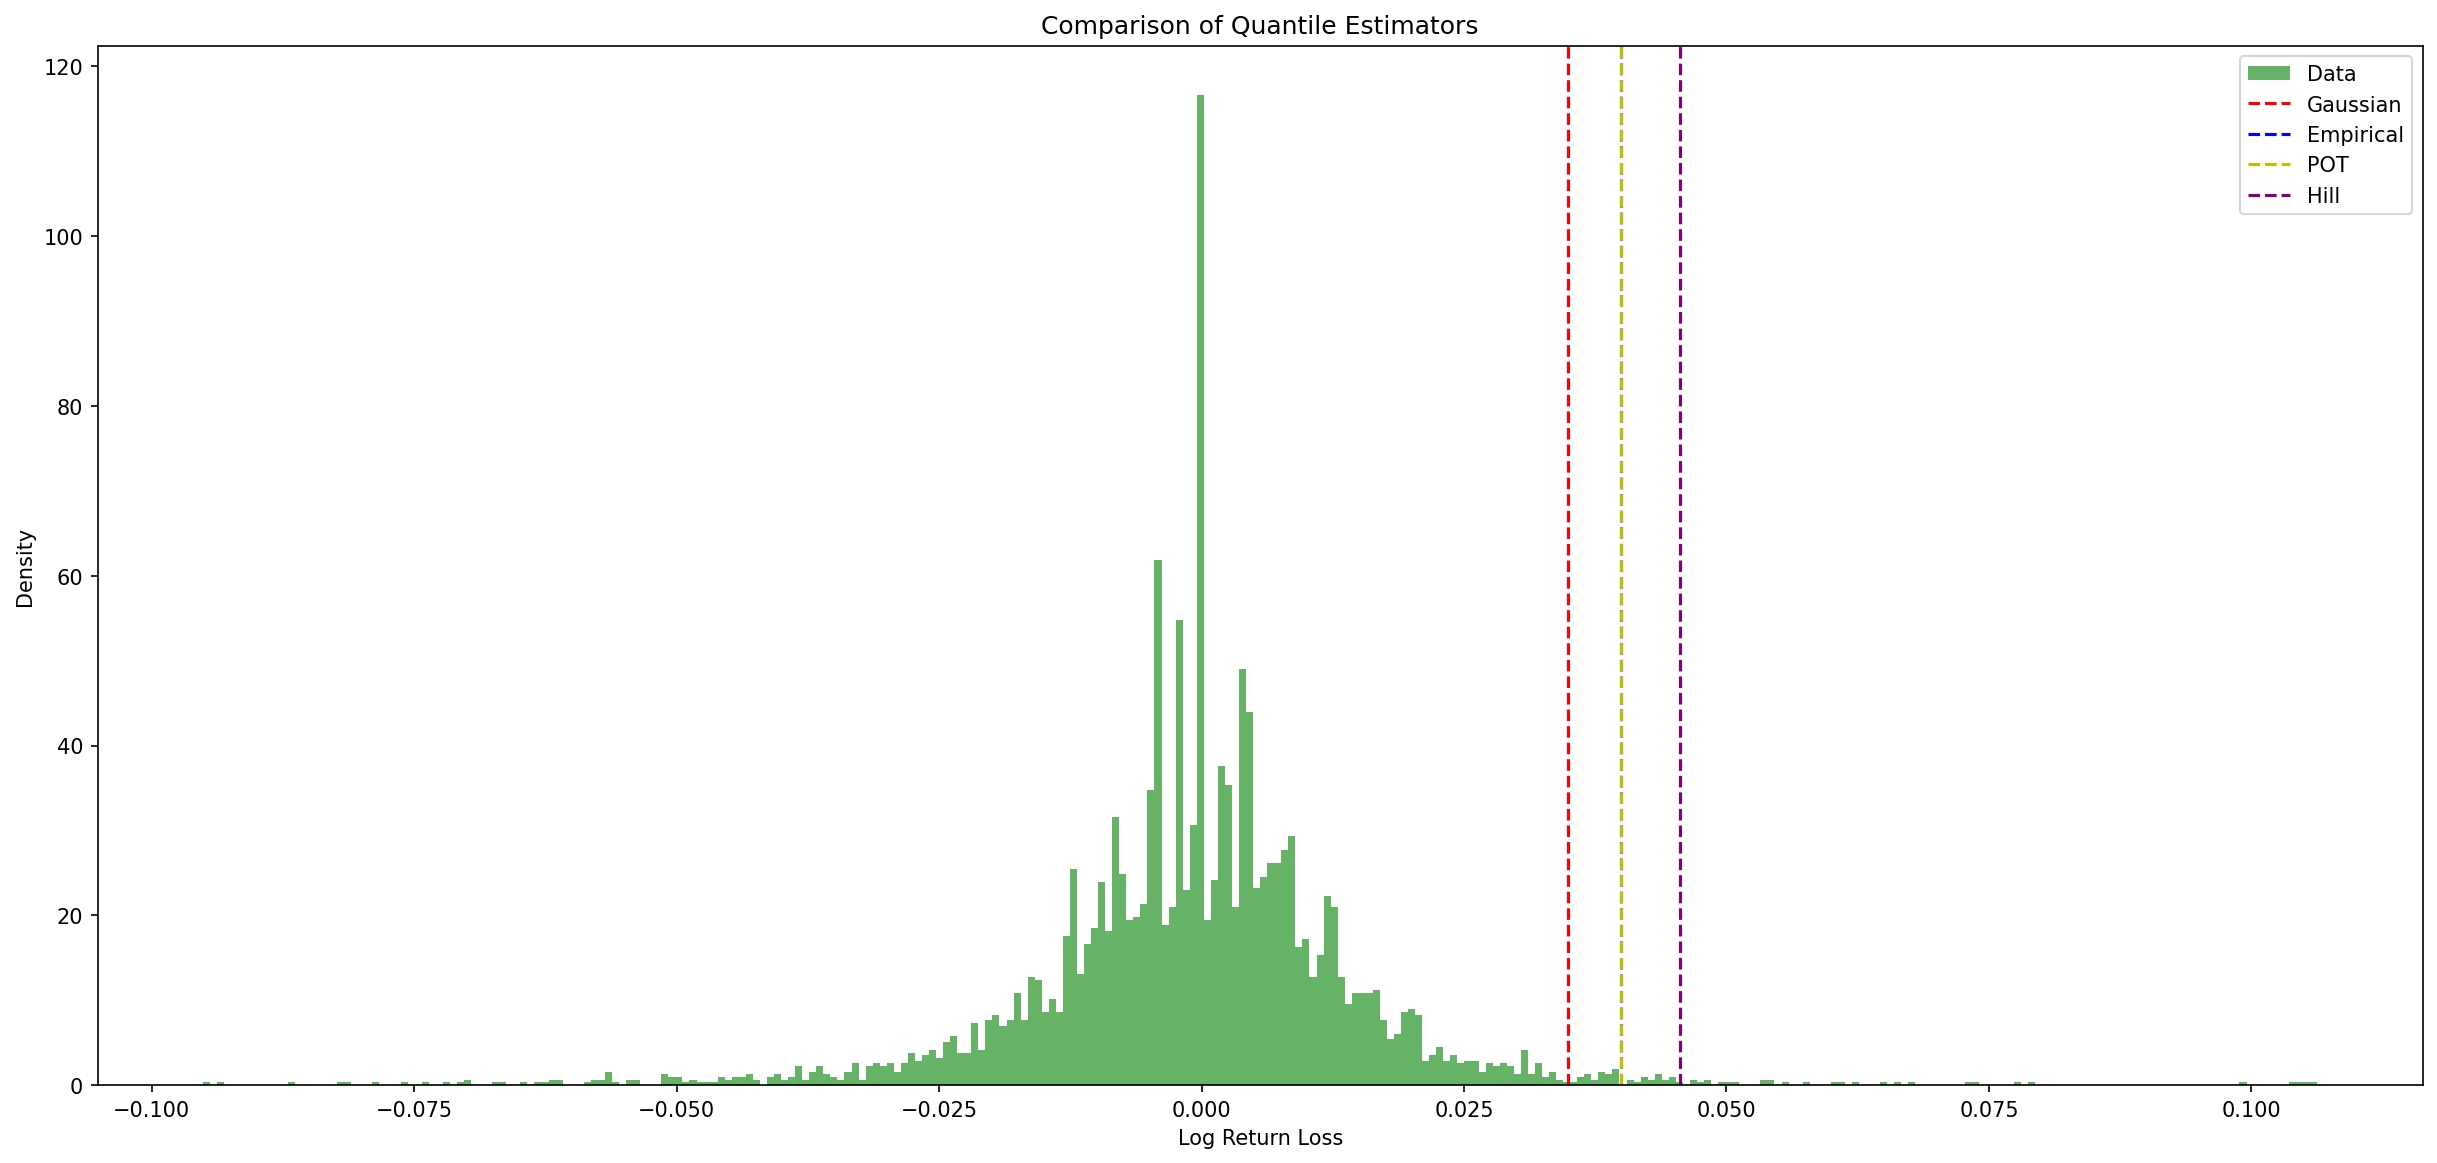

In [132]:
def q_gaussian(data, alpha=0.99):
    mean = np.mean(data)
    std = np.std(data)
    return stats.norm.ppf(alpha, loc=mean, scale=std)


def q_empirical(data, alpha=0.99):
    return np.quantile(data, alpha)


def q_pot(data, alpha=0.99, threshold=0.03):
    exceedances = data[data > threshold] - threshold
    if len(exceedances) == 0:
        q_pot = threshold
    else:
        # 拟合广义帕累托分布
        params = genpareto.fit(exceedances)
        c, loc, scale = params
        T = len(data)
        N = len(exceedances)
        # 计算0.99分位数
        q_pot = threshold + scale / c * ((len(data) / len(exceedances) * (1 - alpha)) ** (-c) - 1)
    return q_pot


def q_hill(data, quantile=0.99, k=650):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]

    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))

    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha


data = loss
pot_threshold = 0.012
hill_k = 650
print(f'Gaussian_loss: {q_gaussian(data):.4f}')
print(f'Empirical_loss: {q_empirical(data):.4f}')
print(f'POT_loss: {q_pot(data, threshold=pot_threshold):.4f}')
print(f'Hill_loss: {q_hill(data, k=hill_k)[0]:.4f}')

plt.figure(figsize=(20, 9), dpi=150)
plt.plot(logreturn.index, data, label='Log Return Loss')
plt.axhline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axhline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axhline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axhline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Log Return Loss')

plt.figure(figsize=(20, 9), dpi=150)
plt.hist(data, bins=300, density=True, alpha=0.6, color='g', label='Data')
plt.axvline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axvline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axvline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axvline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.title("Comparison of Quantile Estimators")
plt.xlabel('Log Return Loss')
plt.ylabel('Density')
plt.show()

# Comparisons

## Normal Distribution

### B

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\425362971.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for threshold in tqdm_notebook(thresholds):


  0%|          | 0/2246 [00:00<?, ?it/s]

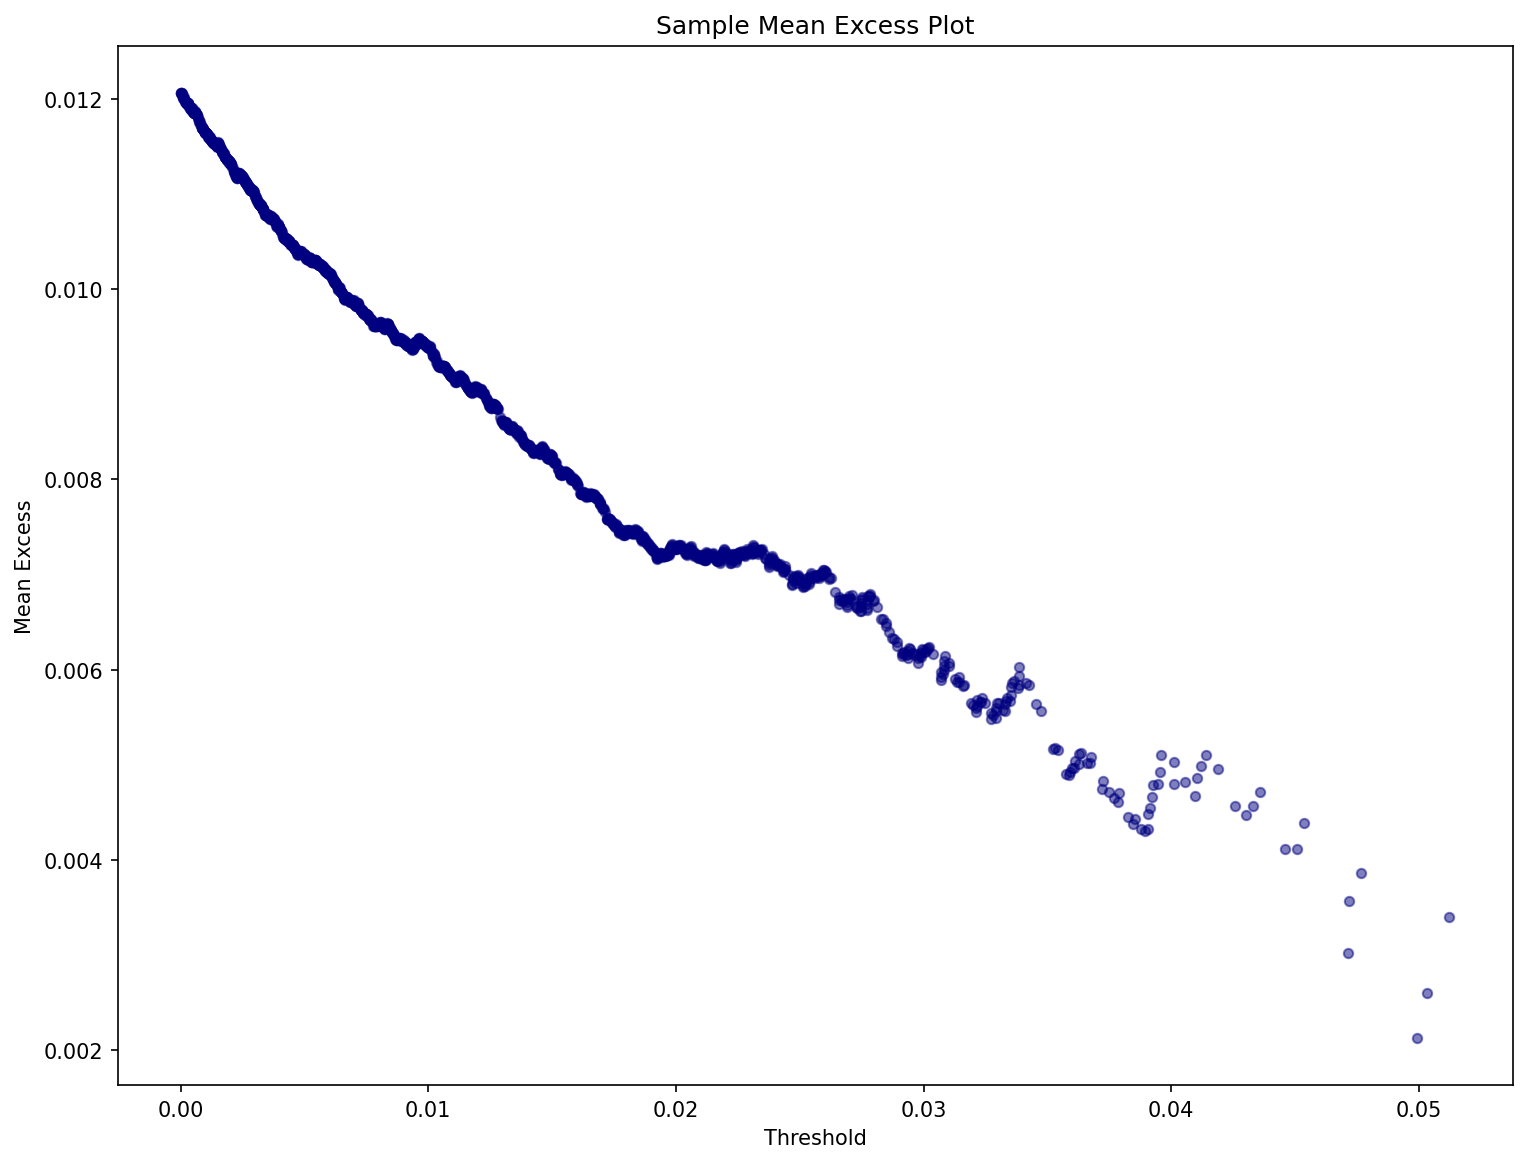

In [90]:
normal = pd.Series(np.random.normal(np.mean(loss), np.std(loss), len(loss)))
plot_figB(normal)

### C

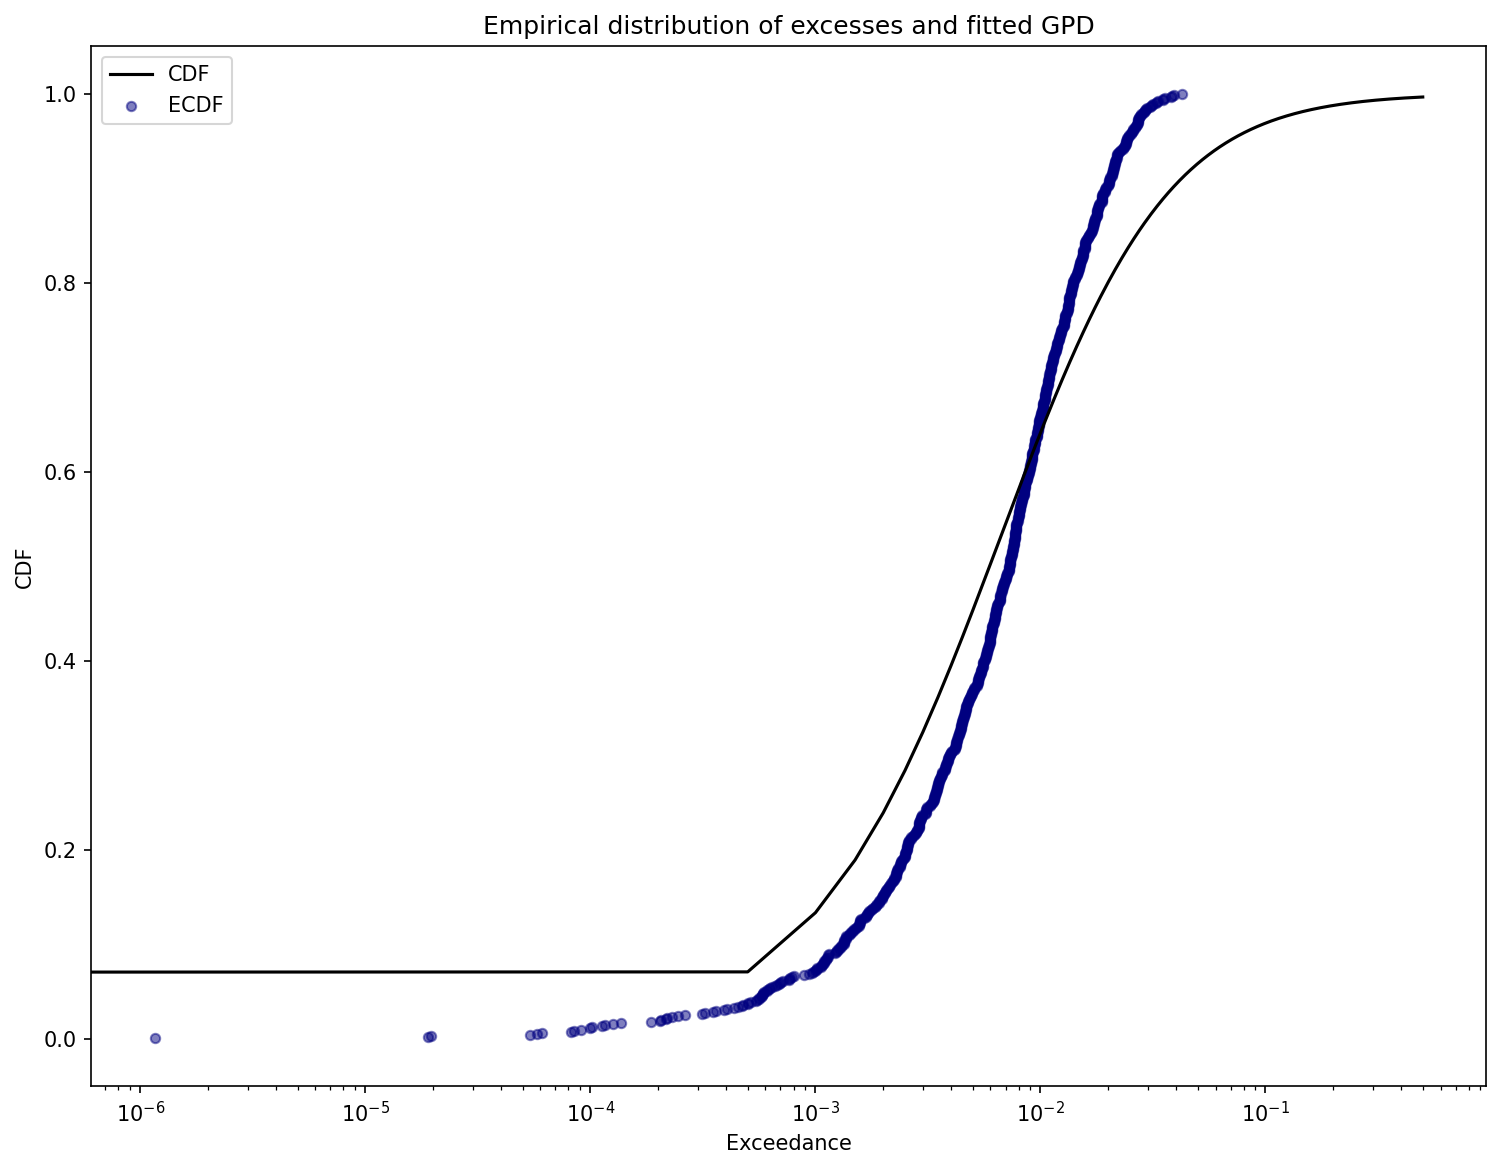

c: 0.7093100214711868
loc: 1.1582857600924477e-06
scale: 0.006641902029894273
Num: 932


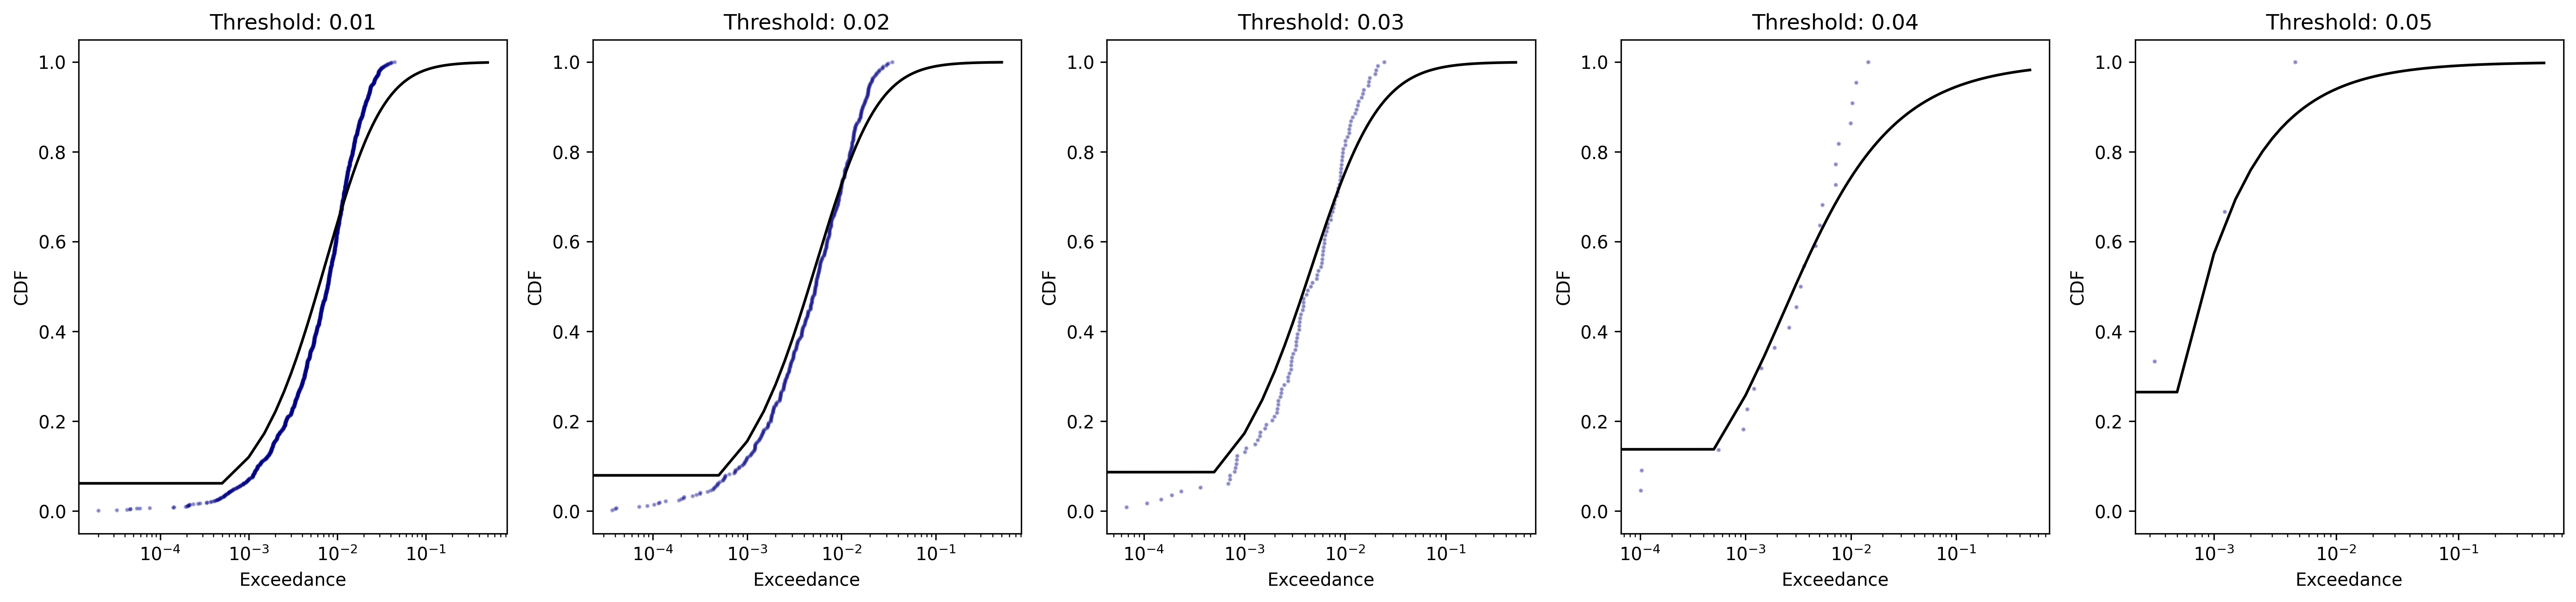

In [93]:
plot_figC(normal, 0.012)

# subplots for thresholds from 0.01 to 0.08
fig, axs = plt.subplots(1, 5, figsize=(25, 5), dpi=300)
# log scale X axis
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.05, 5), axs.flatten()):
    exceedances = normal[normal > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.2f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\3476689934.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\615994365.py:32: RuntimeWarning: invalid value encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))


Text(0.5, 1.0, 'Hill Estimator of Alpha')

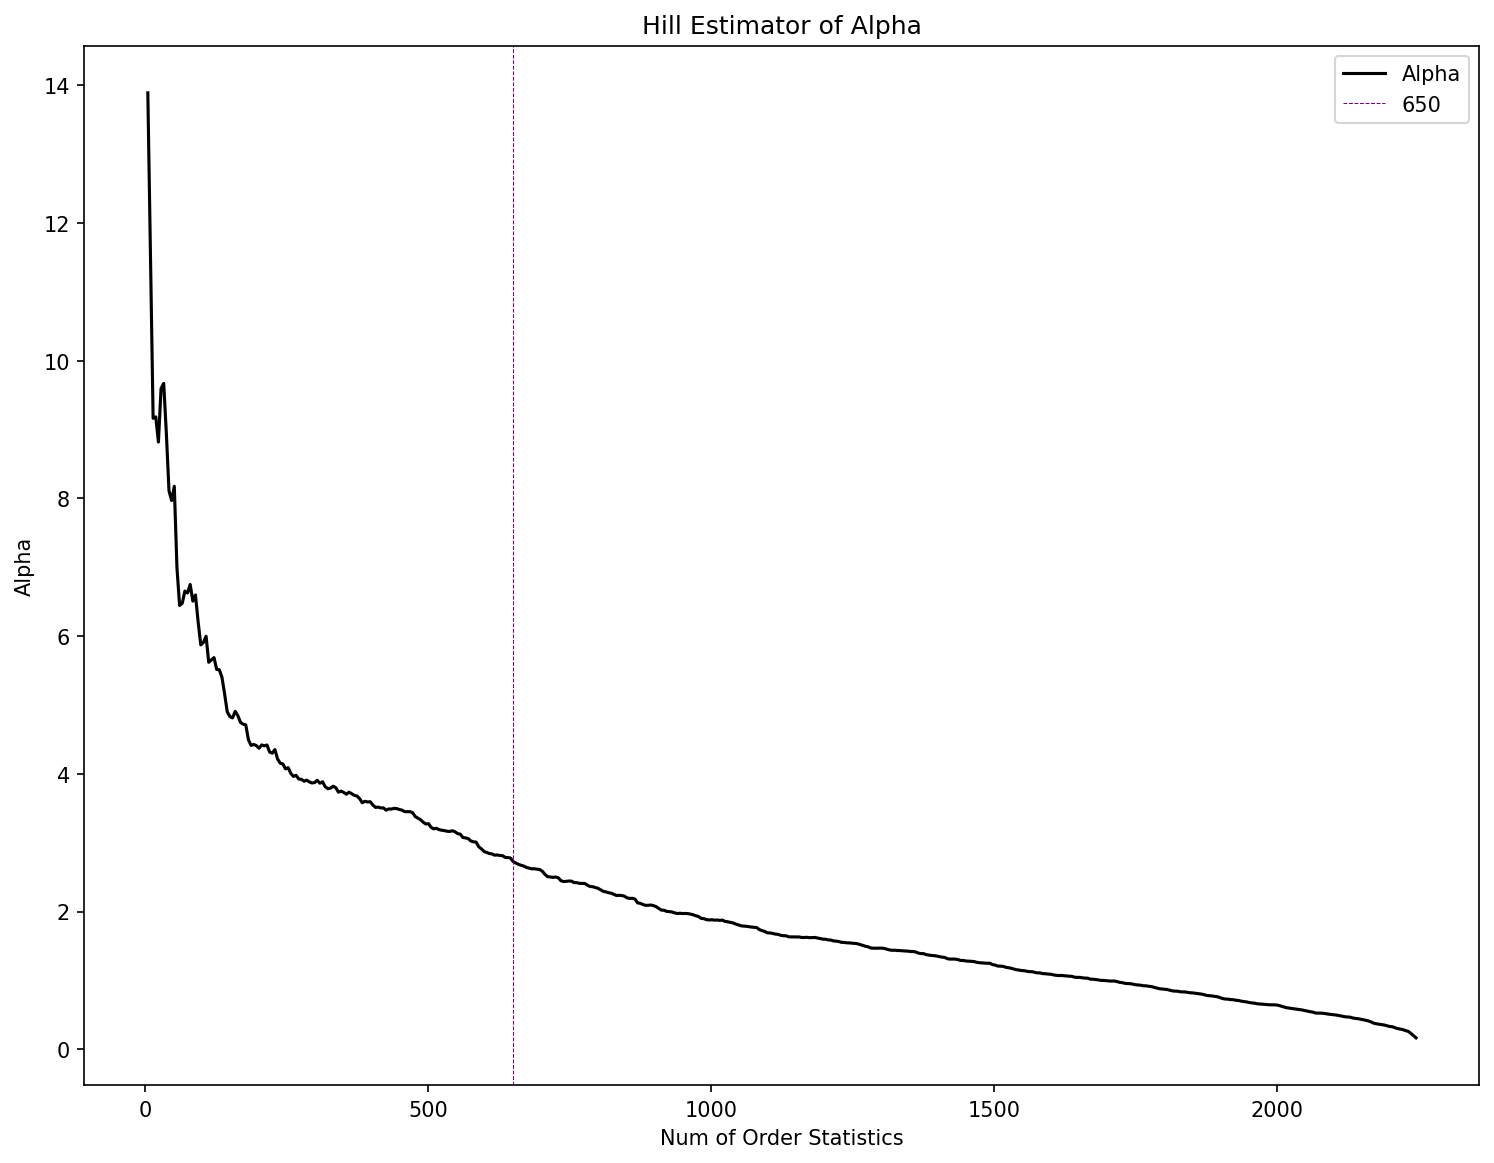

In [96]:
alphas = []
ks = np.linspace(5, 4676, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(normal, quantile=0.99, k=int(k))
    alphas.append(alpha)

plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')

plt.axvline(650, color='purple', linestyle='--', label='650', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

## Industry Index

### B

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\425362971.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for threshold in tqdm_notebook(thresholds):


  0%|          | 0/2498 [00:00<?, ?it/s]

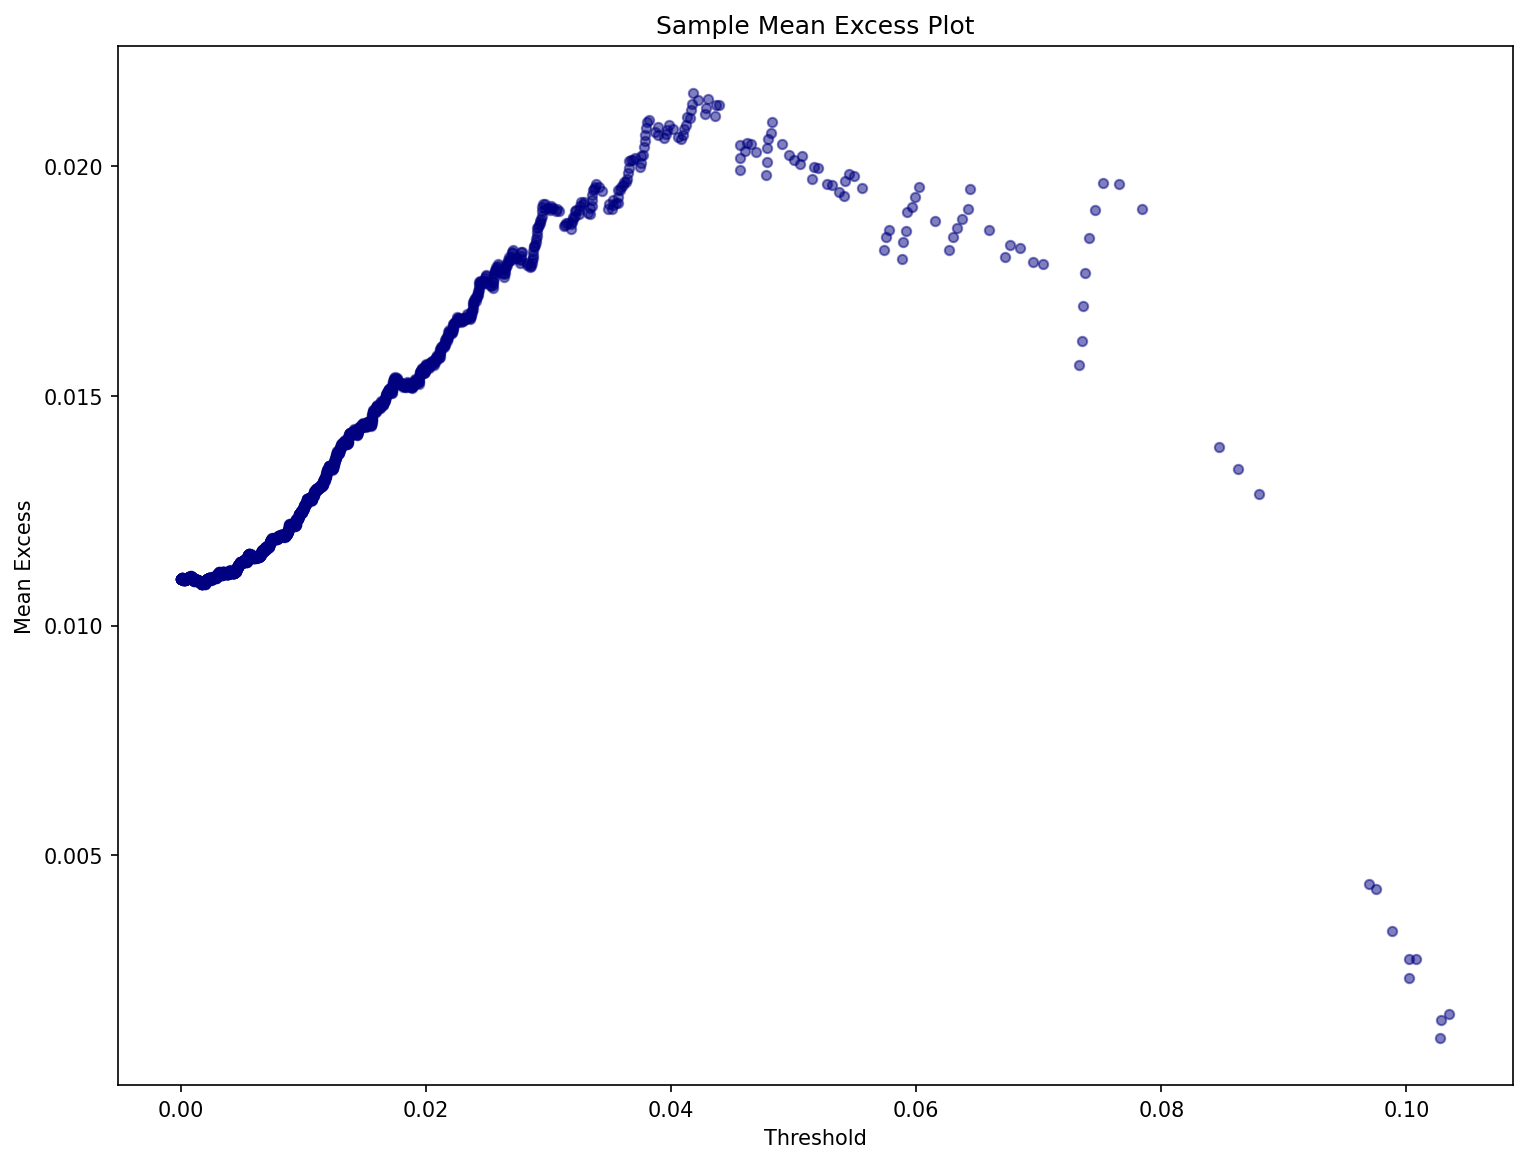

日期
2003-11-19   -0.005575
2003-11-20   -0.015971
2003-11-21    0.008910
2003-11-24   -0.030512
2003-11-25    0.001605
                ...   
2024-12-27   -0.011235
2024-12-30    0.009614
2024-12-31    0.003373
2025-01-02    0.023091
2025-01-03    0.009621
Name: logreturn, Length: 5134, dtype: float64

In [114]:
data_industry = pd.read_excel('882528.WI.xlsx')
data_industry['logreturn'] = np.log(data_industry['收盘价(元)']/data_industry['收盘价(元)'].shift(1))
data_industry.dropna(inplace=True)
logreturn_industry = data_industry[['logreturn', '日期']].set_index('日期')
logreturn_industry = logreturn_industry.loc['2003-11-19':]
loss_industry = - logreturn_industry['logreturn']
plot_figB(loss_industry)
loss_industry

### C

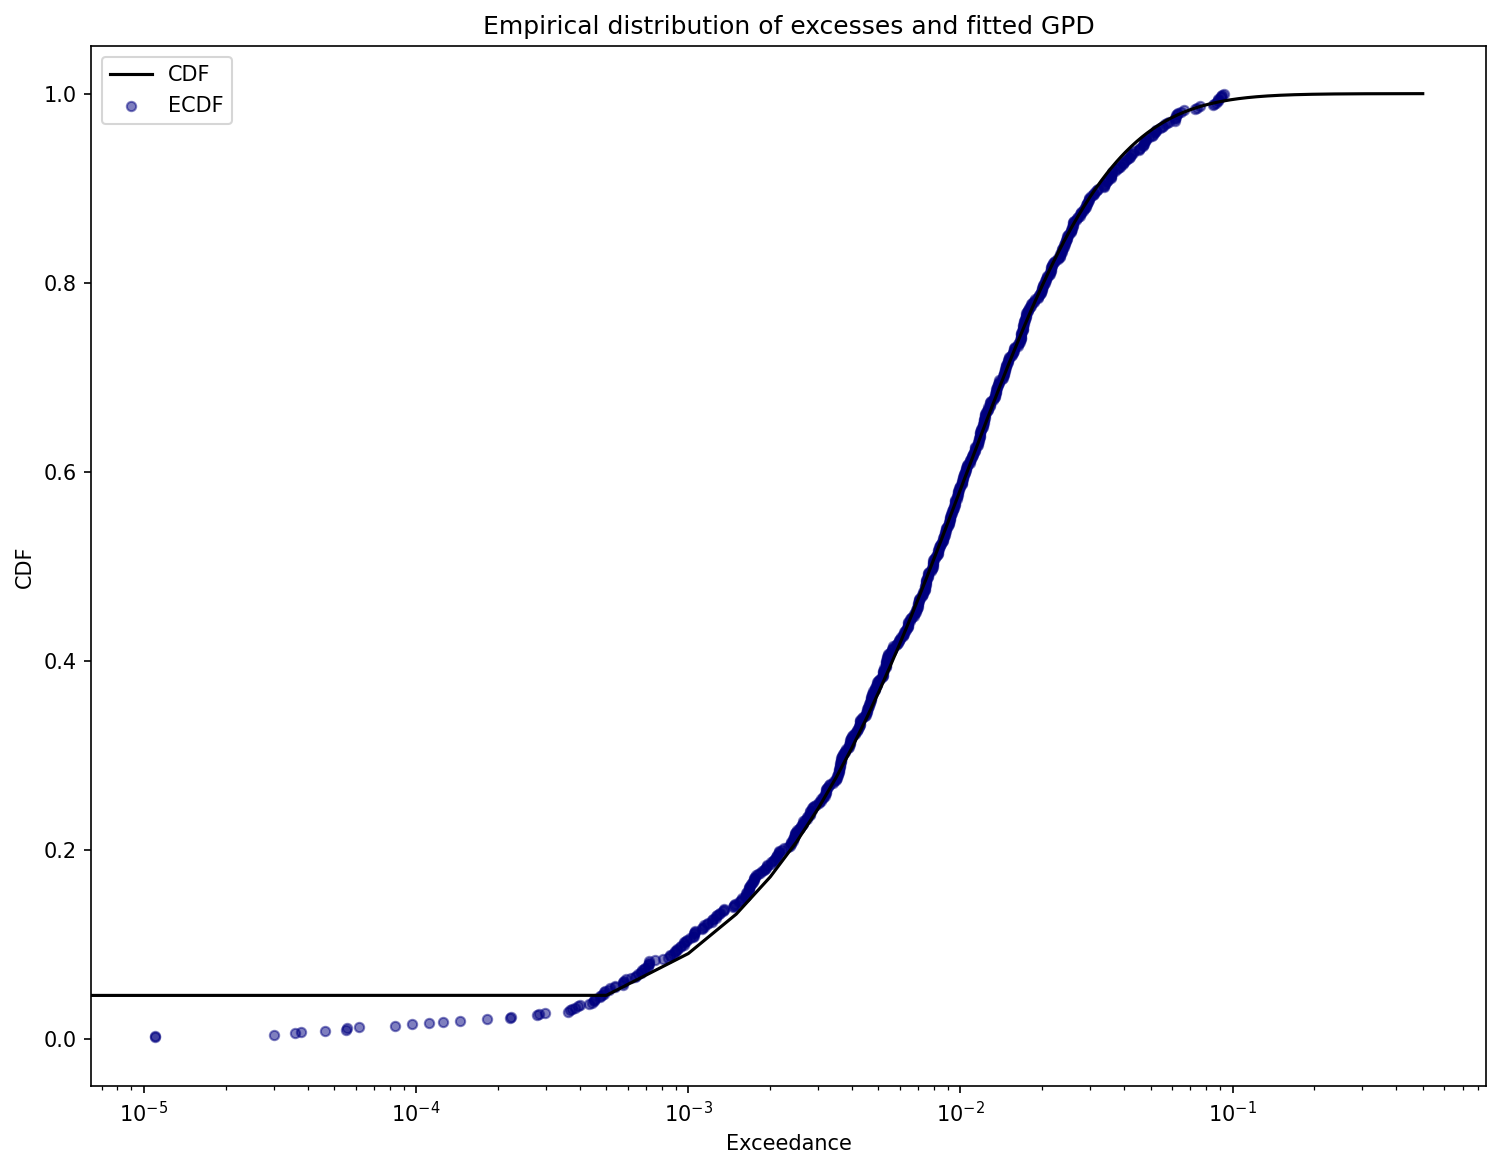

c: 0.22932102415203387
loc: 1.0952142322656139e-05
scale: 0.010381947846792913
Num: 735


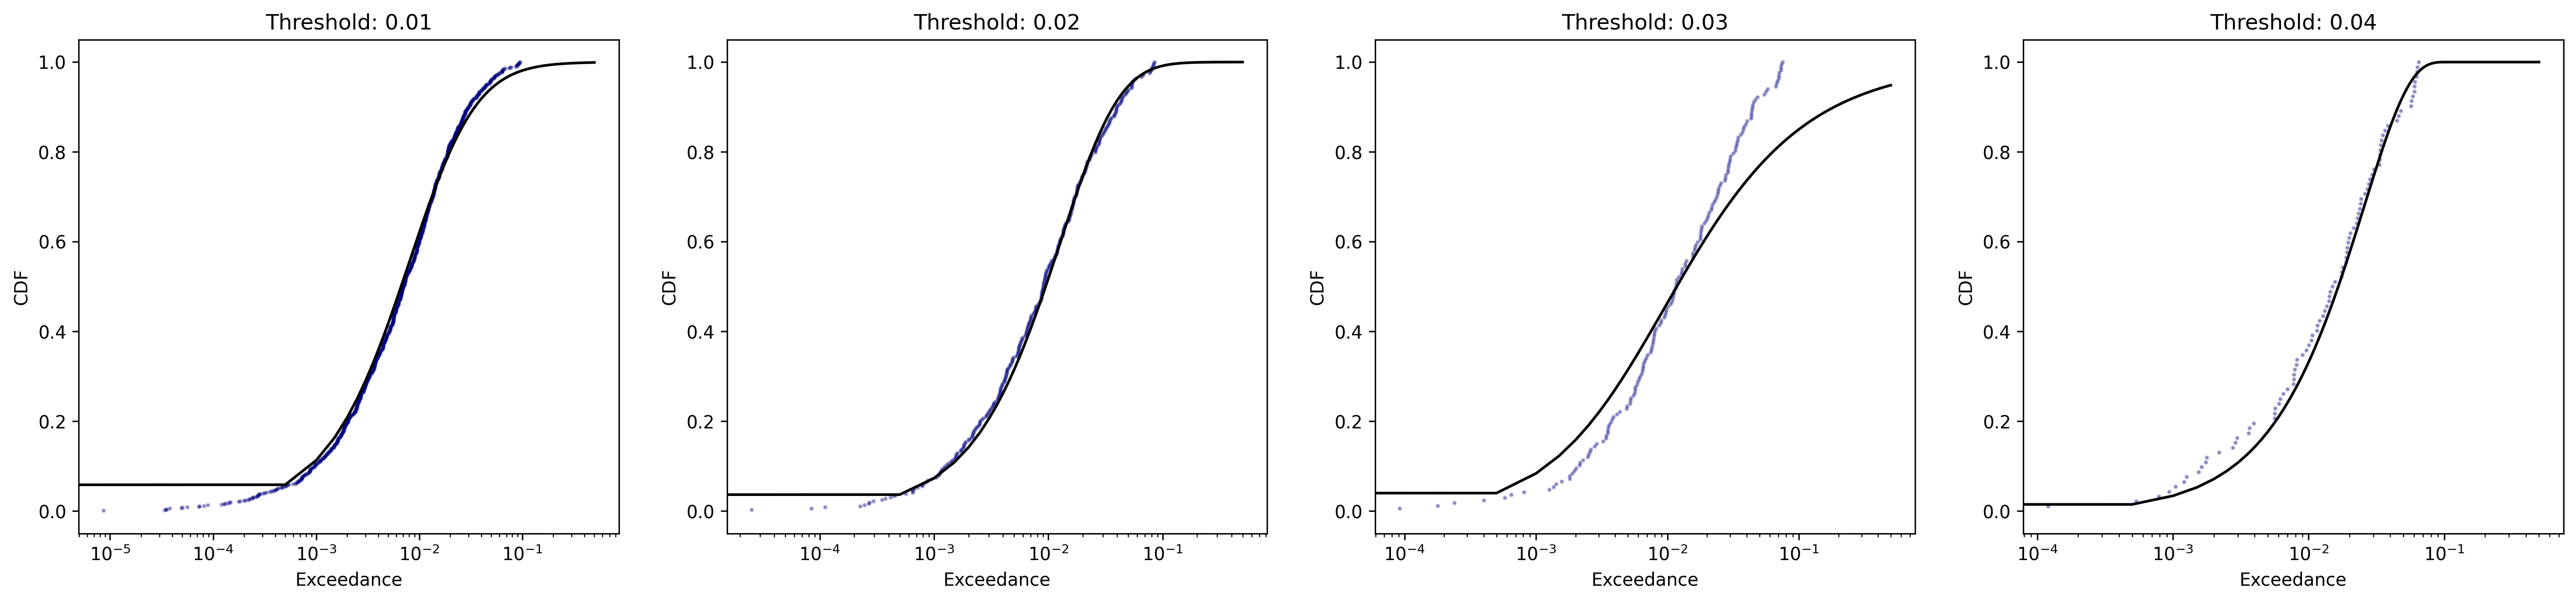

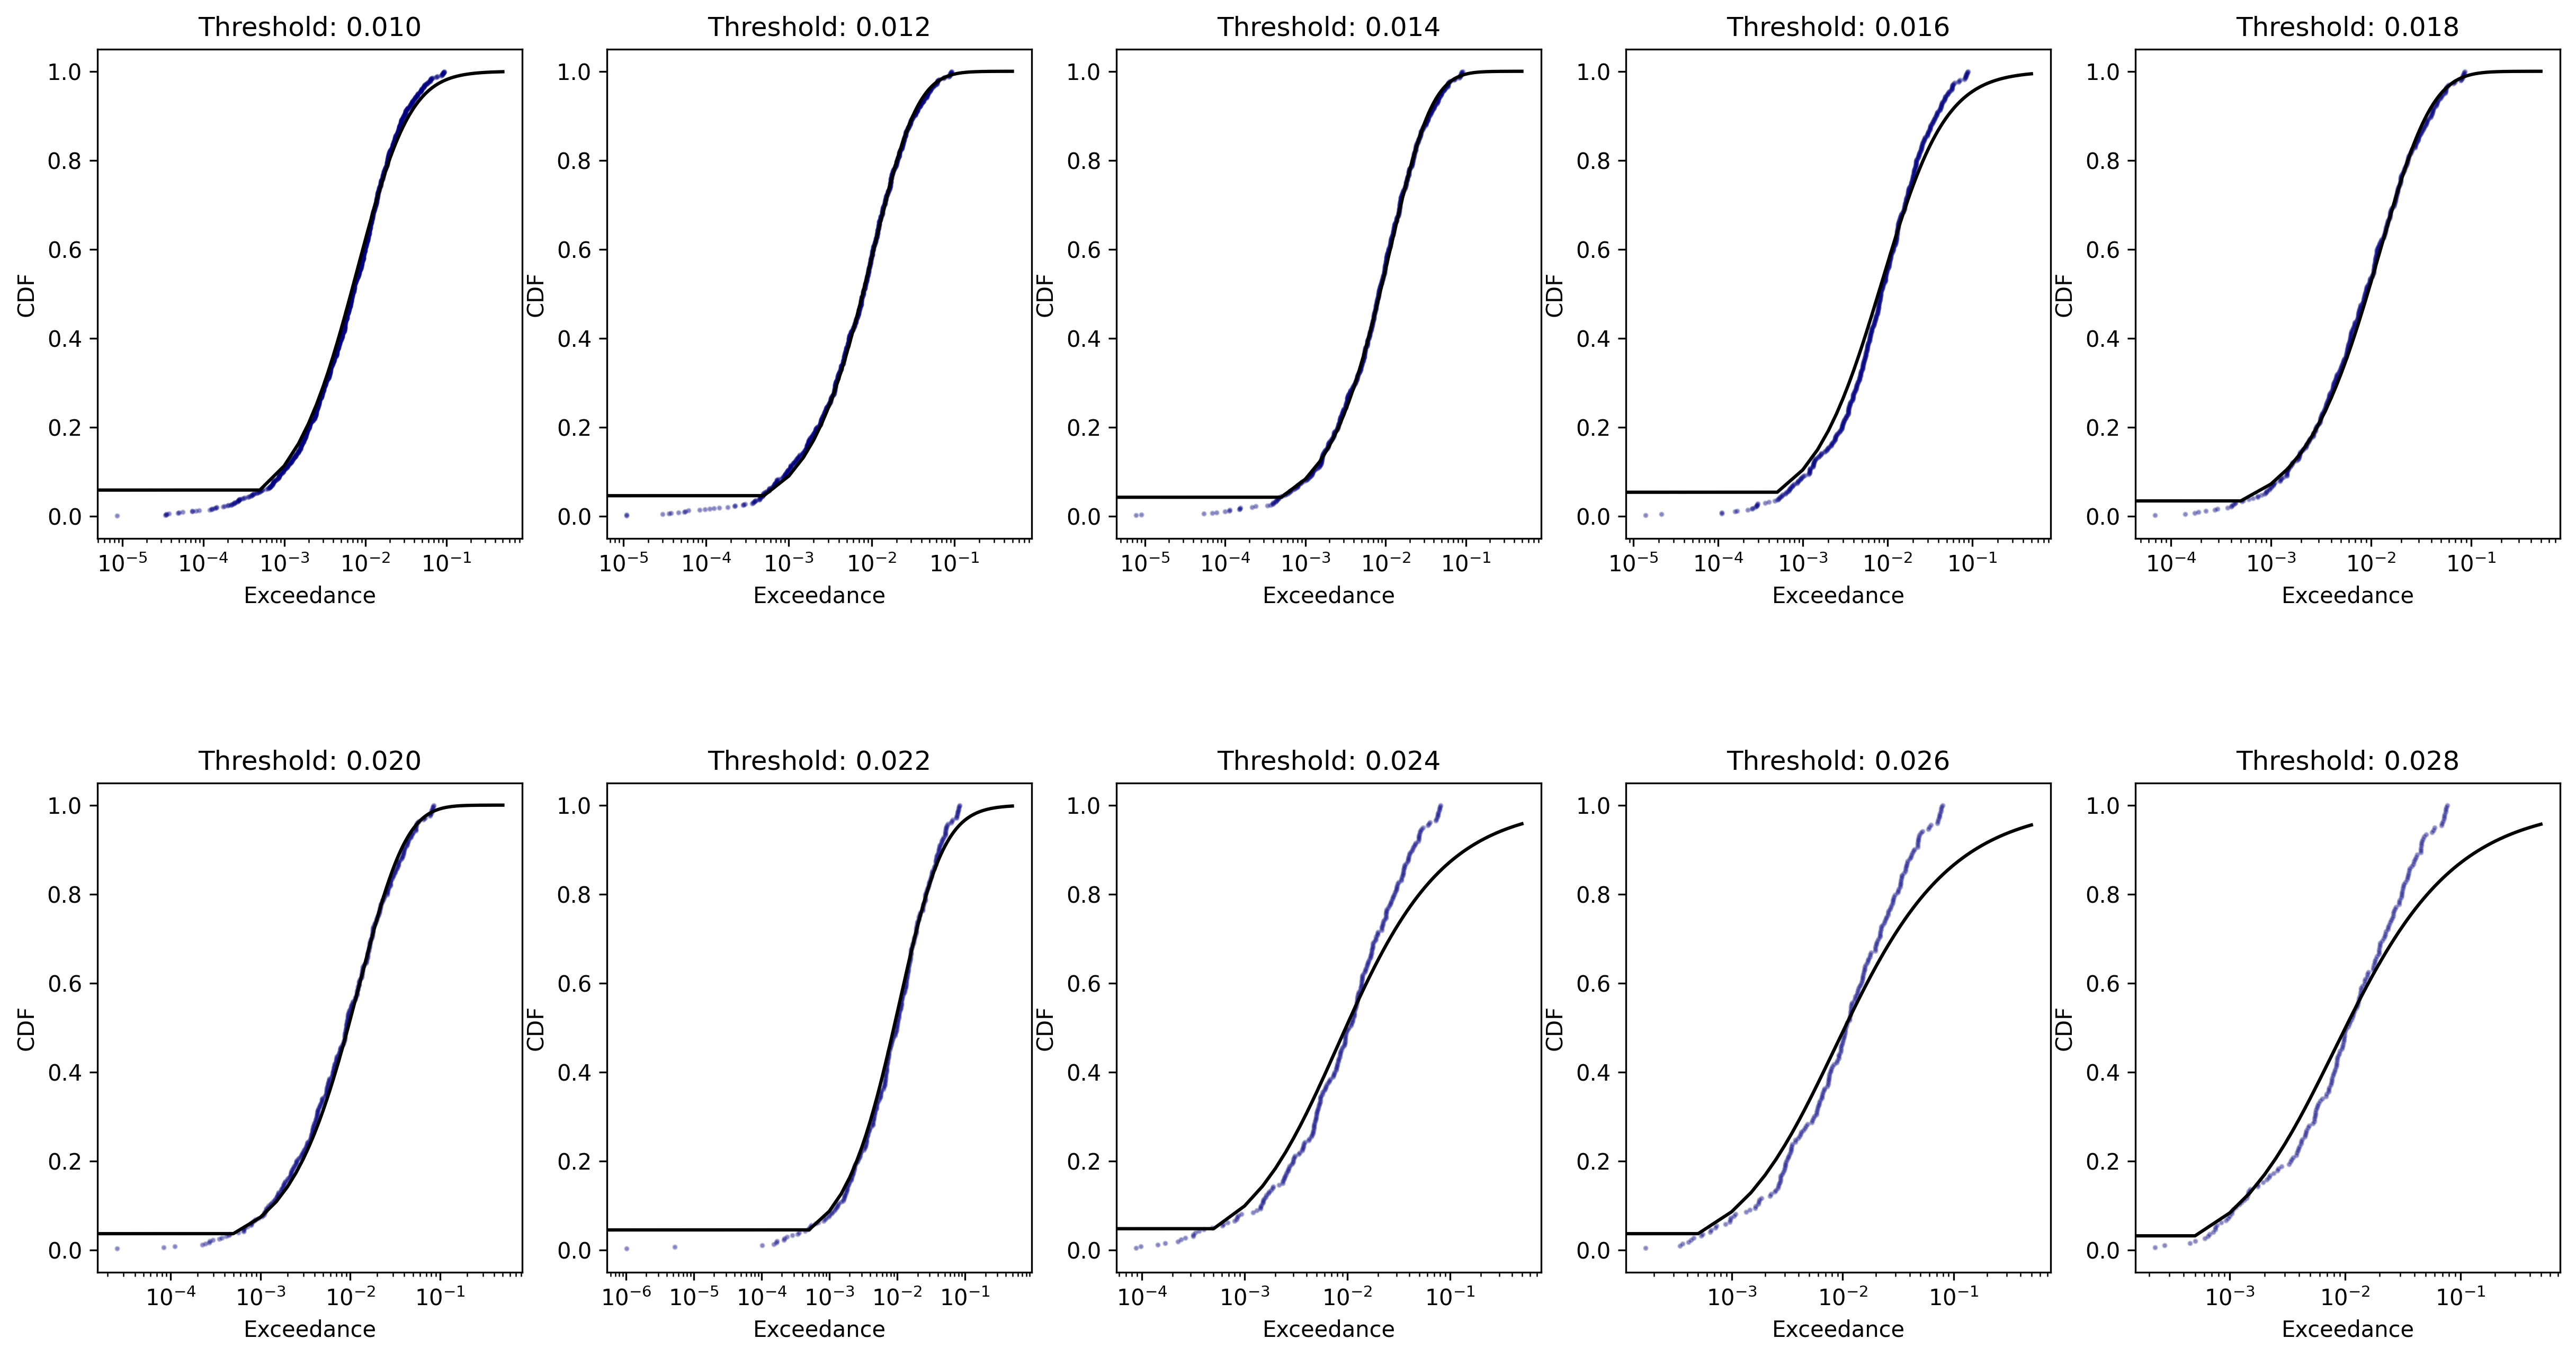

In [125]:
plot_figC(loss_industry, 0.012)

# subplots for thresholds from 0.01 to 0.08
fig, axs = plt.subplots(1, 4, figsize=(25, 5), dpi=300)
# log scale X axis
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.04, 4), axs.flatten()):
    exceedances = loss_industry[loss_industry > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.2f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

fig, axs = plt.subplots(2, 5, figsize=(20, 10), dpi=300)
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.028, 10), axs.flatten()):
    exceedances = loss_industry[loss_industry > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.3f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

### Hill

Hill_loss:, 0.0509


C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\817631484.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\817631484.py:5: RuntimeWarning: invalid value encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\817631484.py:29: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Hill Estimator of Alpha')

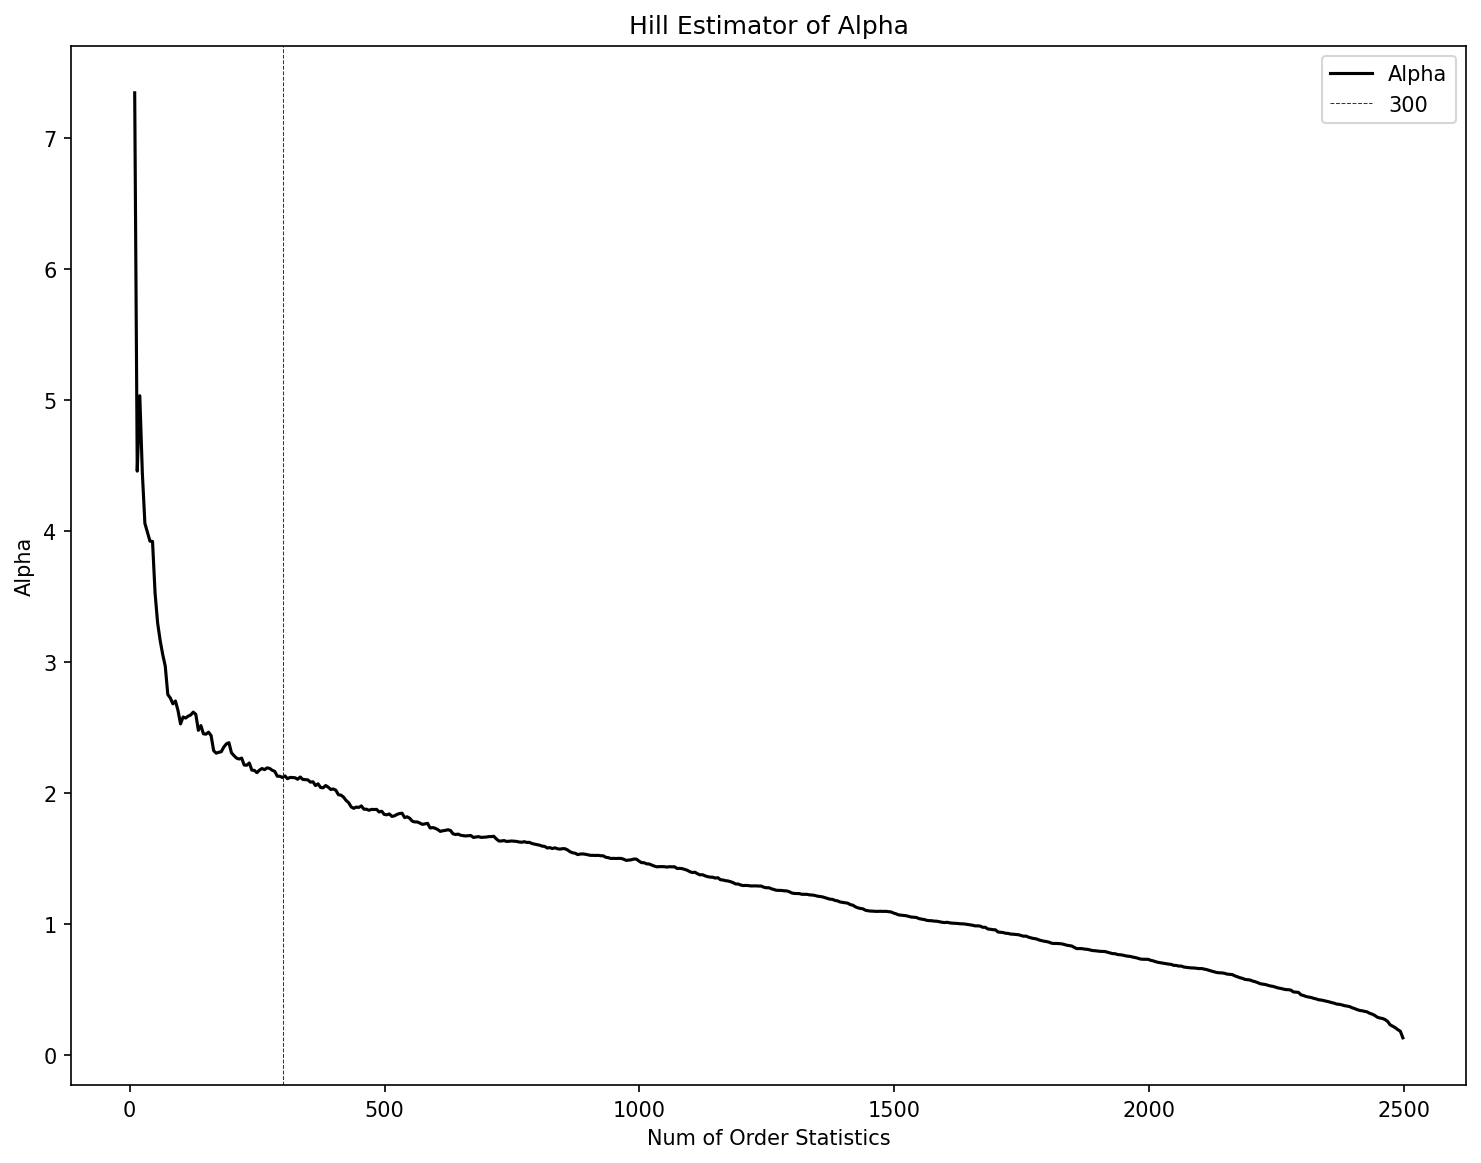

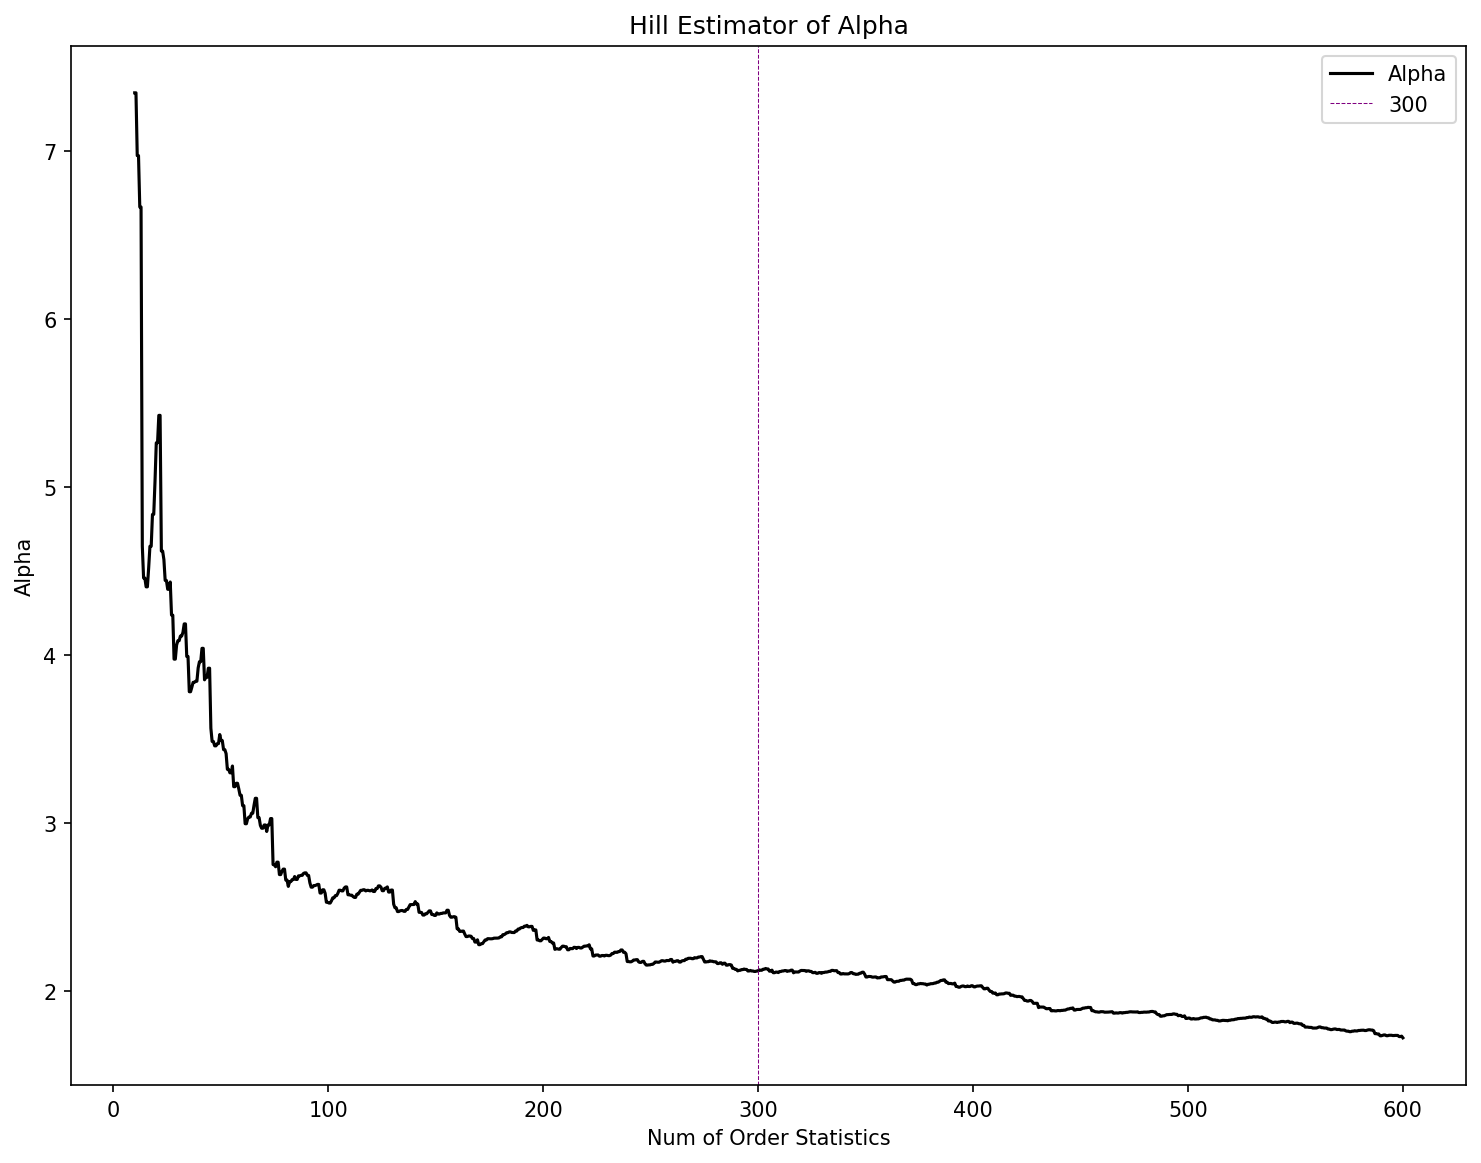

In [117]:
def q_hill(data, quantile=0.99, k=500):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]
    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha

print(f'Hill_loss:, {q_hill(loss_industry, k=300)[0]:.4f}')

alphas = []
ks = np.linspace(10, 5000, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(loss_industry, quantile=0.99, k=int(k))
    alphas.append(alpha)
plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')
plt.axvline(300, color='purple', linestyle='--', label='300', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

alphas = []
ks = np.linspace(10, 600, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(loss_industry, quantile=0.99, k=int(k))
    alphas.append(alpha)
plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')
plt.axvline(300, color='purple', linestyle='--', label='300', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

### Big Plot

Gaussian_loss: 0.0379
Empirical_loss: 0.0530
POT_loss: 0.0501
Hill_loss: 0.0509


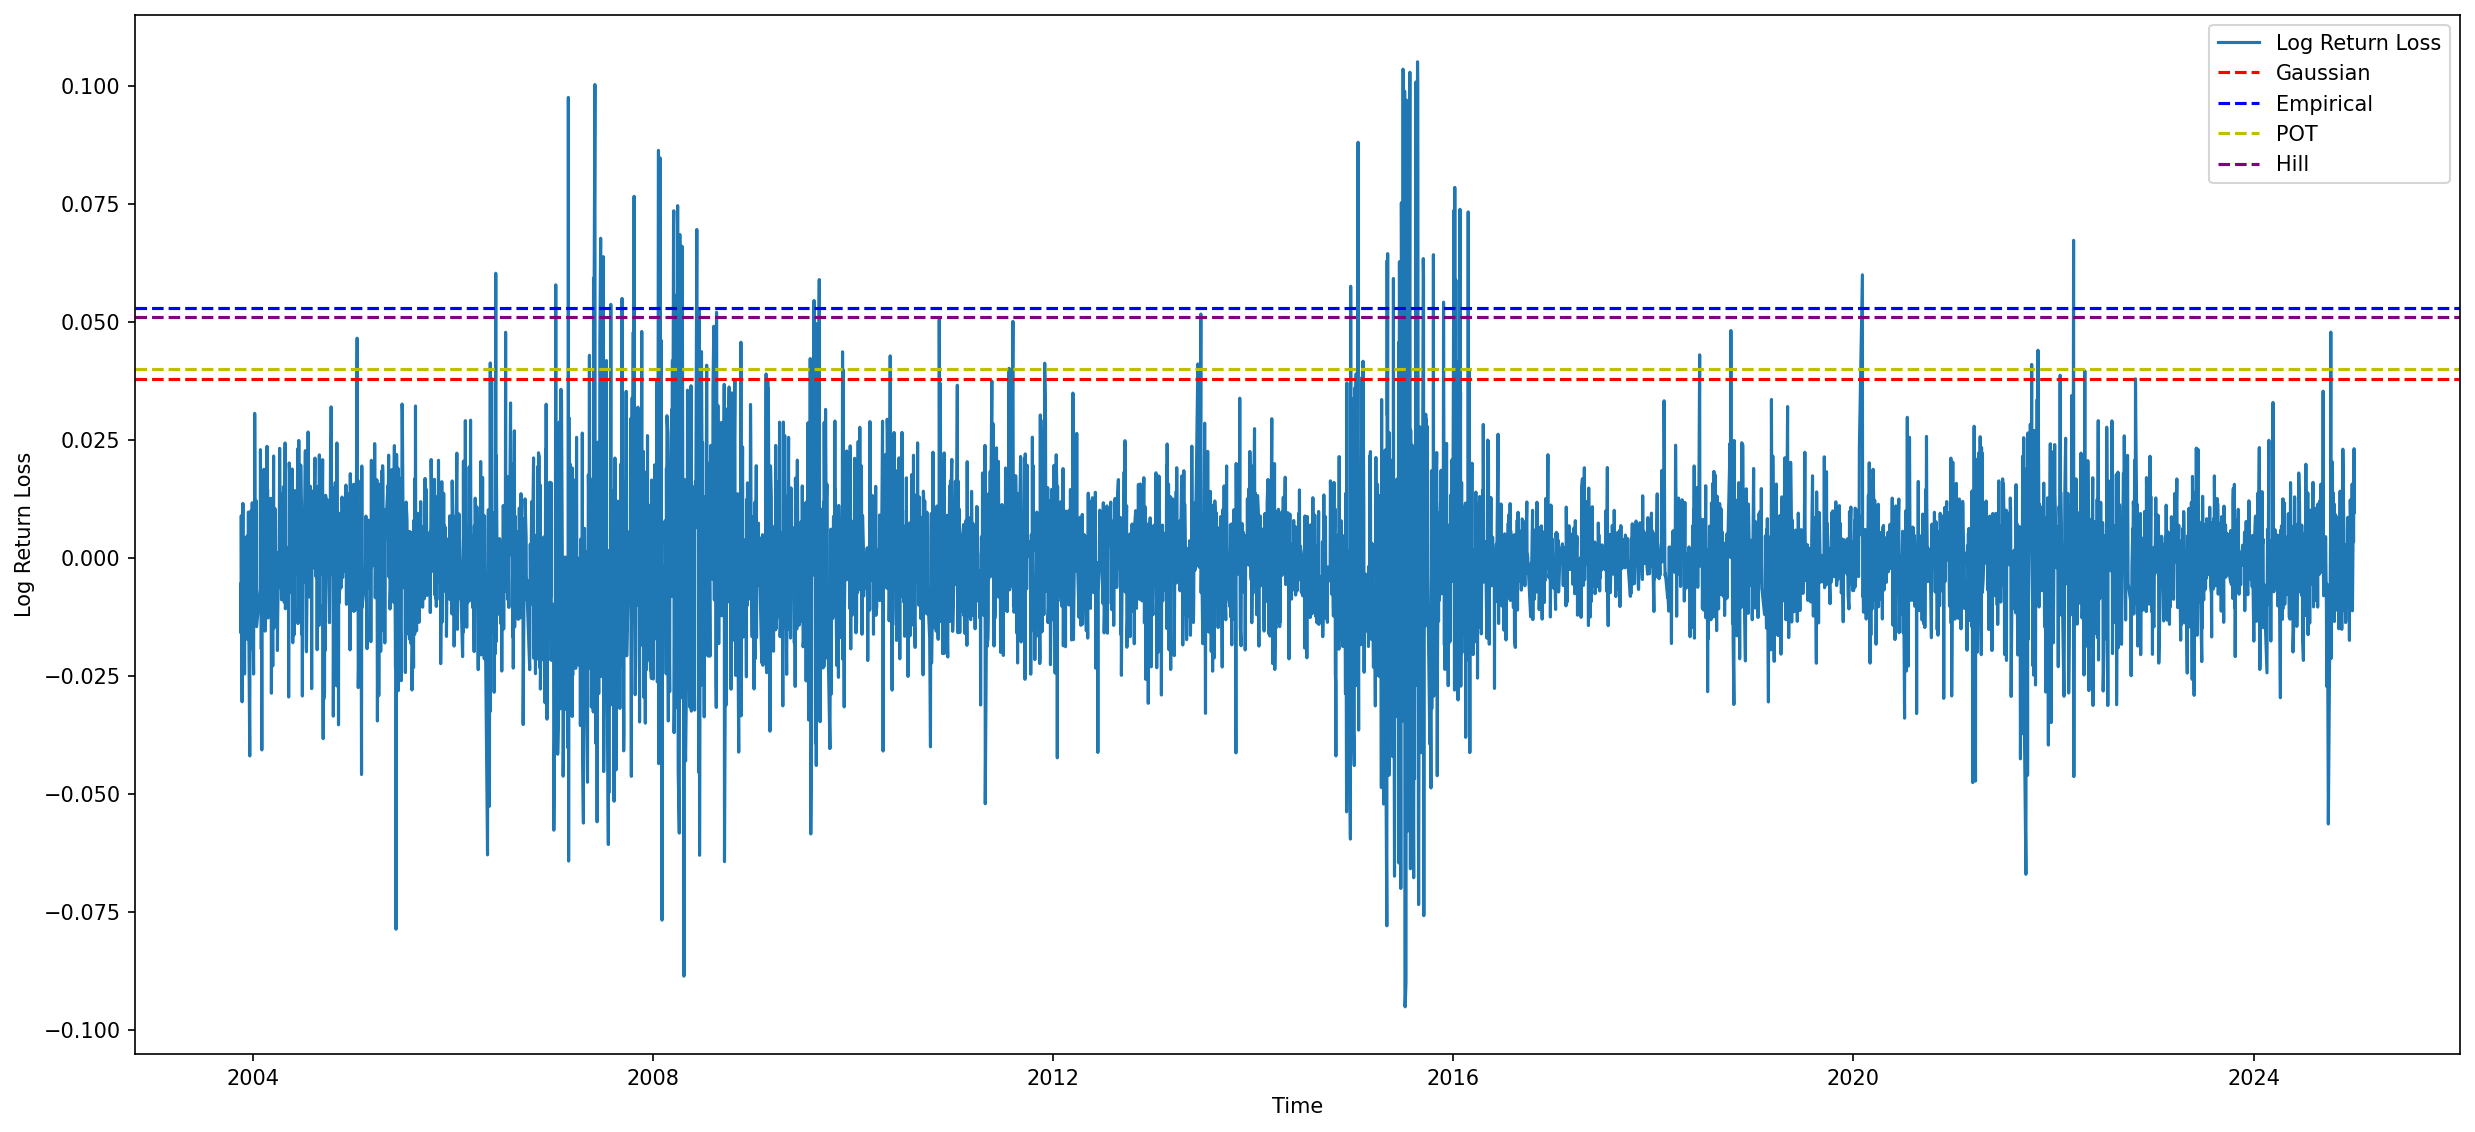

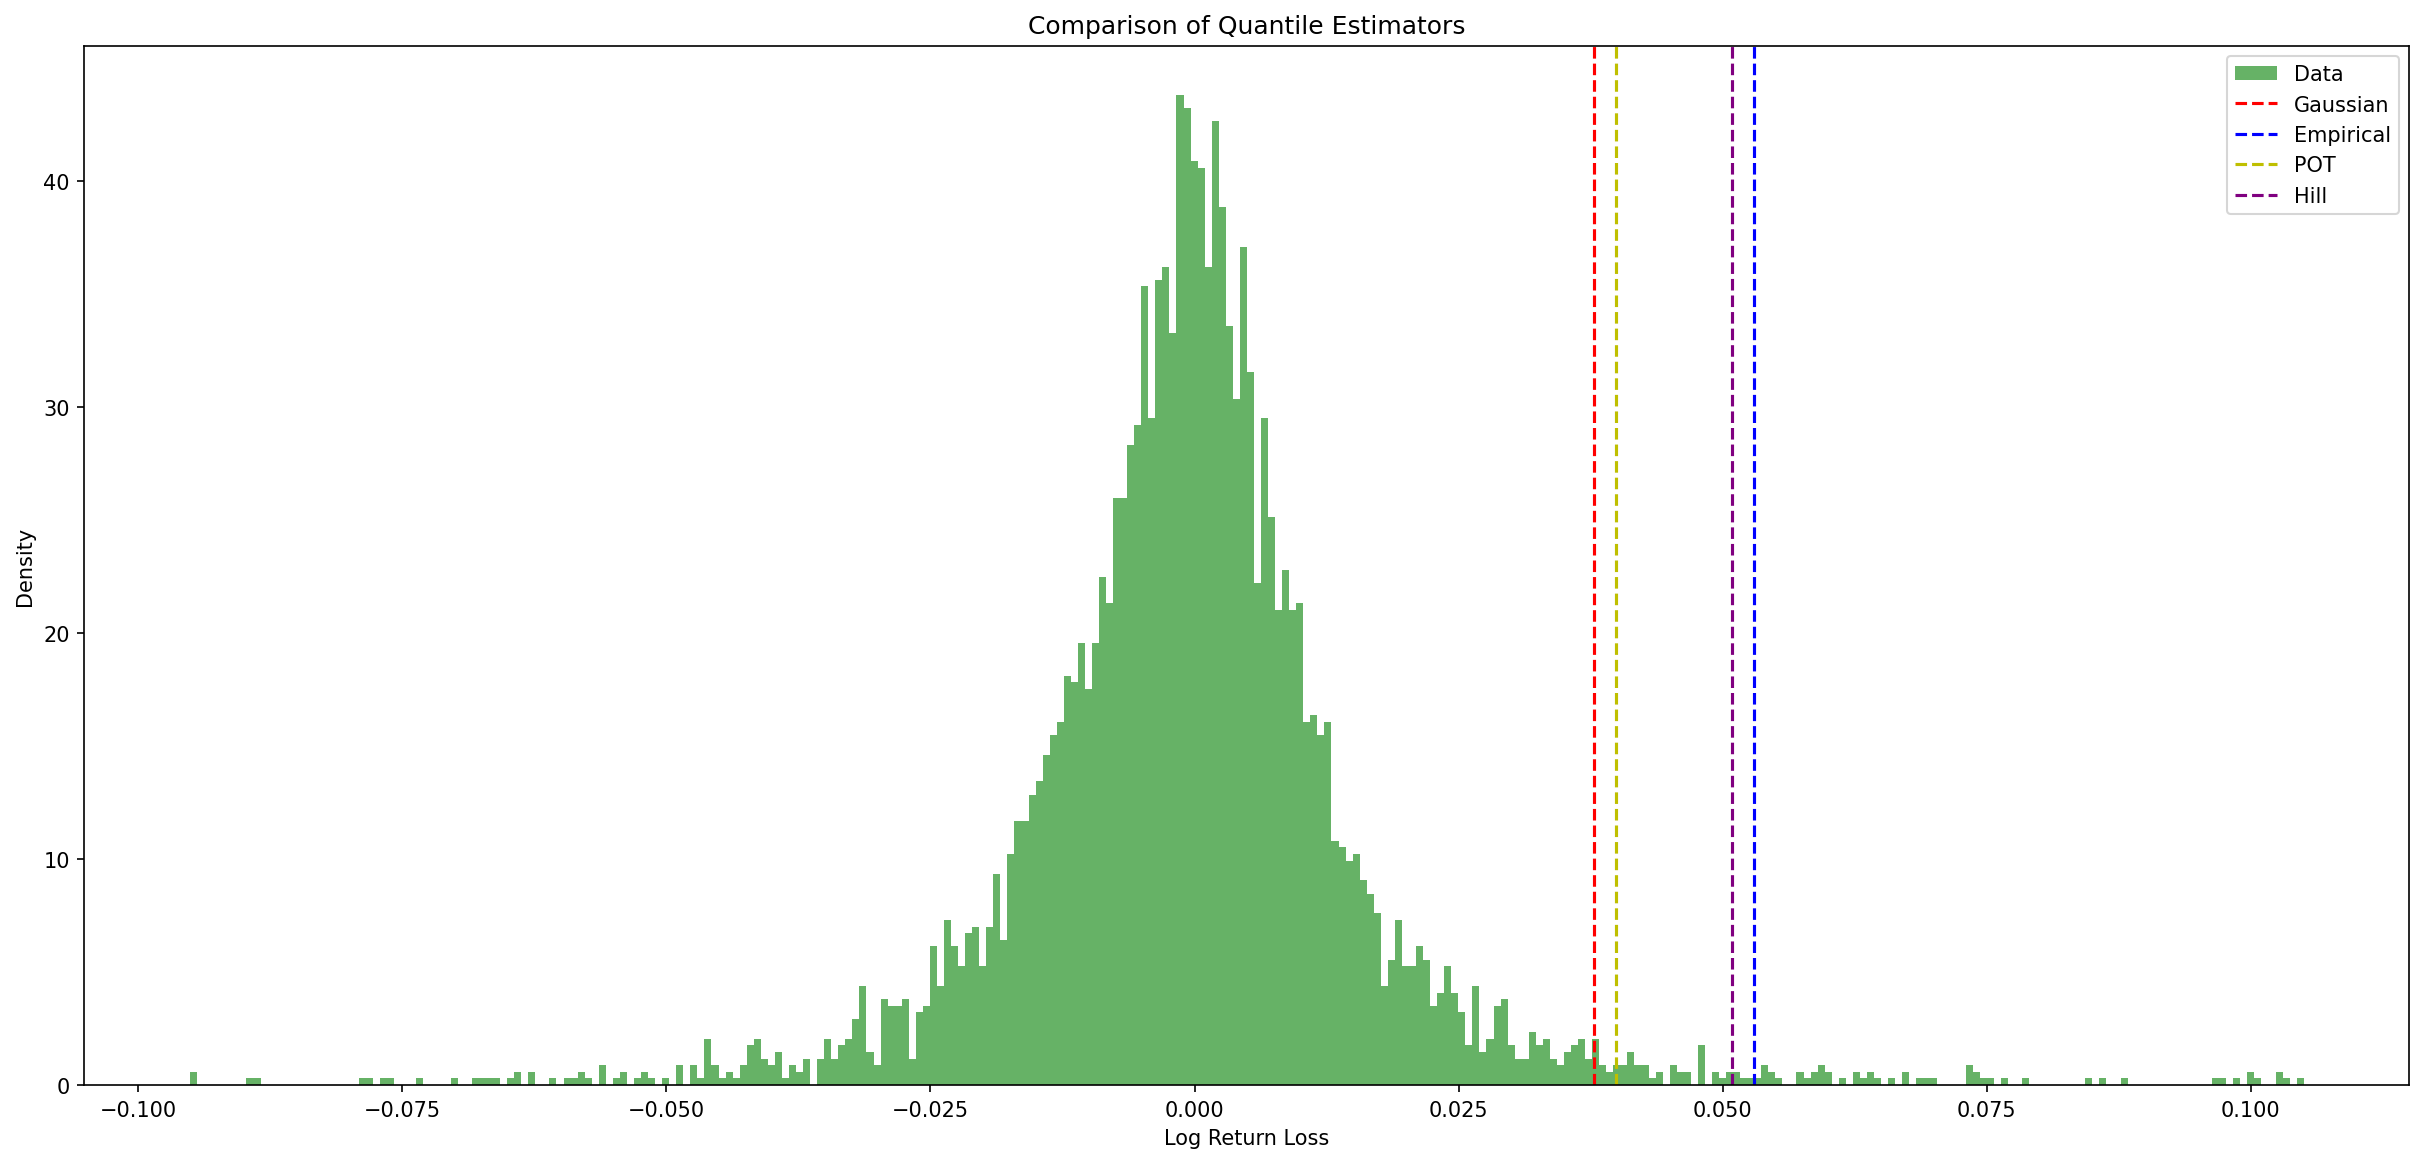

In [133]:
def q_gaussian(data, alpha=0.99):
    mean = np.mean(data)
    std = np.std(data)
    return stats.norm.ppf(alpha, loc=mean, scale=std)


def q_empirical(data, alpha=0.99):
    return np.quantile(data, alpha)


def q_pot(data, alpha=0.99, threshold=0.03):
    exceedances = data[data > threshold] - threshold
    if len(exceedances) == 0:
        q_pot = threshold
    else:
        # 拟合广义帕累托分布
        params = genpareto.fit(exceedances)
        c, loc, scale = params
        T = len(data)
        N = len(exceedances)
        # 计算0.99分位数
        q_pot = threshold + scale / c * ((len(data) / len(exceedances) * (1 - alpha)) ** (-c) - 1)
    return q_pot


def q_hill(data, quantile=0.99, k=650):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]

    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))

    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha


data = loss_industry
pot_threshold = 0.012
hill_k = 300
print(f'Gaussian_loss: {q_gaussian(data):.4f}')
print(f'Empirical_loss: {q_empirical(data):.4f}')
print(f'POT_loss: {q_pot(data, threshold=pot_threshold):.4f}')
print(f'Hill_loss: {q_hill(data, k=hill_k)[0]:.4f}')

plt.figure(figsize=(20, 9), dpi=150)
plt.plot(logreturn_industry.index, data, label='Log Return Loss')
plt.axhline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axhline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axhline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axhline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Log Return Loss')

plt.figure(figsize=(20, 9), dpi=150)
plt.hist(data, bins=300, density=True, alpha=0.6, color='g', label='Data')
plt.axvline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axvline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axvline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axvline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.title("Comparison of Quantile Estimators")
plt.xlabel('Log Return Loss')
plt.ylabel('Density')
plt.show()

## 000300

### B

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\425362971.py:9: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for threshold in tqdm_notebook(thresholds):


  0%|          | 0/2460 [00:00<?, ?it/s]

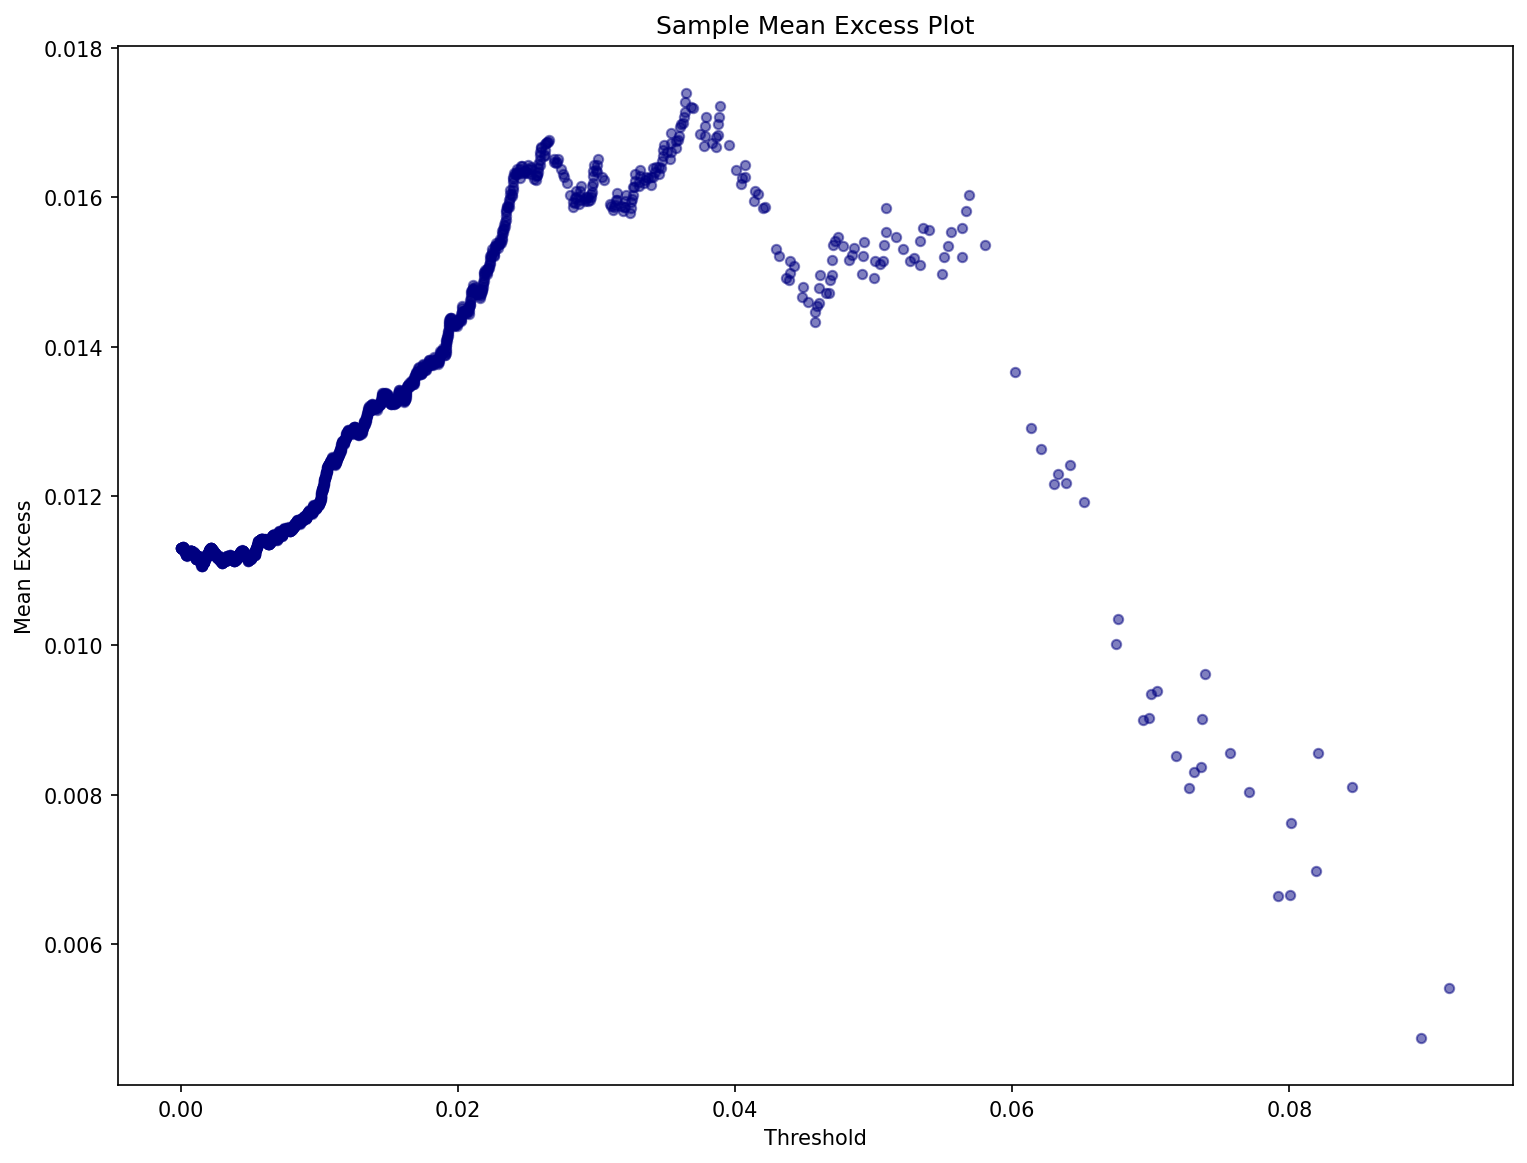

日期
2003-11-19   -0.015649
2003-11-20   -0.027912
2003-11-21    0.012172
2003-11-24   -0.028388
2003-11-25   -0.003436
                ...   
2024-12-27    0.001619
2024-12-30   -0.004516
2024-12-31    0.016169
2025-01-02    0.029533
2025-01-03    0.011912
Name: logreturn, Length: 5134, dtype: float64

In [119]:
data_hs300 = pd.read_excel('000300.SH.xlsx')
data_hs300['logreturn'] = np.log(data_hs300['收盘价(元)']/data_hs300['收盘价(元)'].shift(1))
data_hs300.dropna(inplace=True)
logreturn_hs300 = data_hs300[['logreturn', '日期']].set_index('日期')
logreturn_hs300 = logreturn_hs300.loc['2003-11-19':]
loss_hs300 = - logreturn_hs300['logreturn']
plot_figB(loss_hs300)
loss_hs300

### C

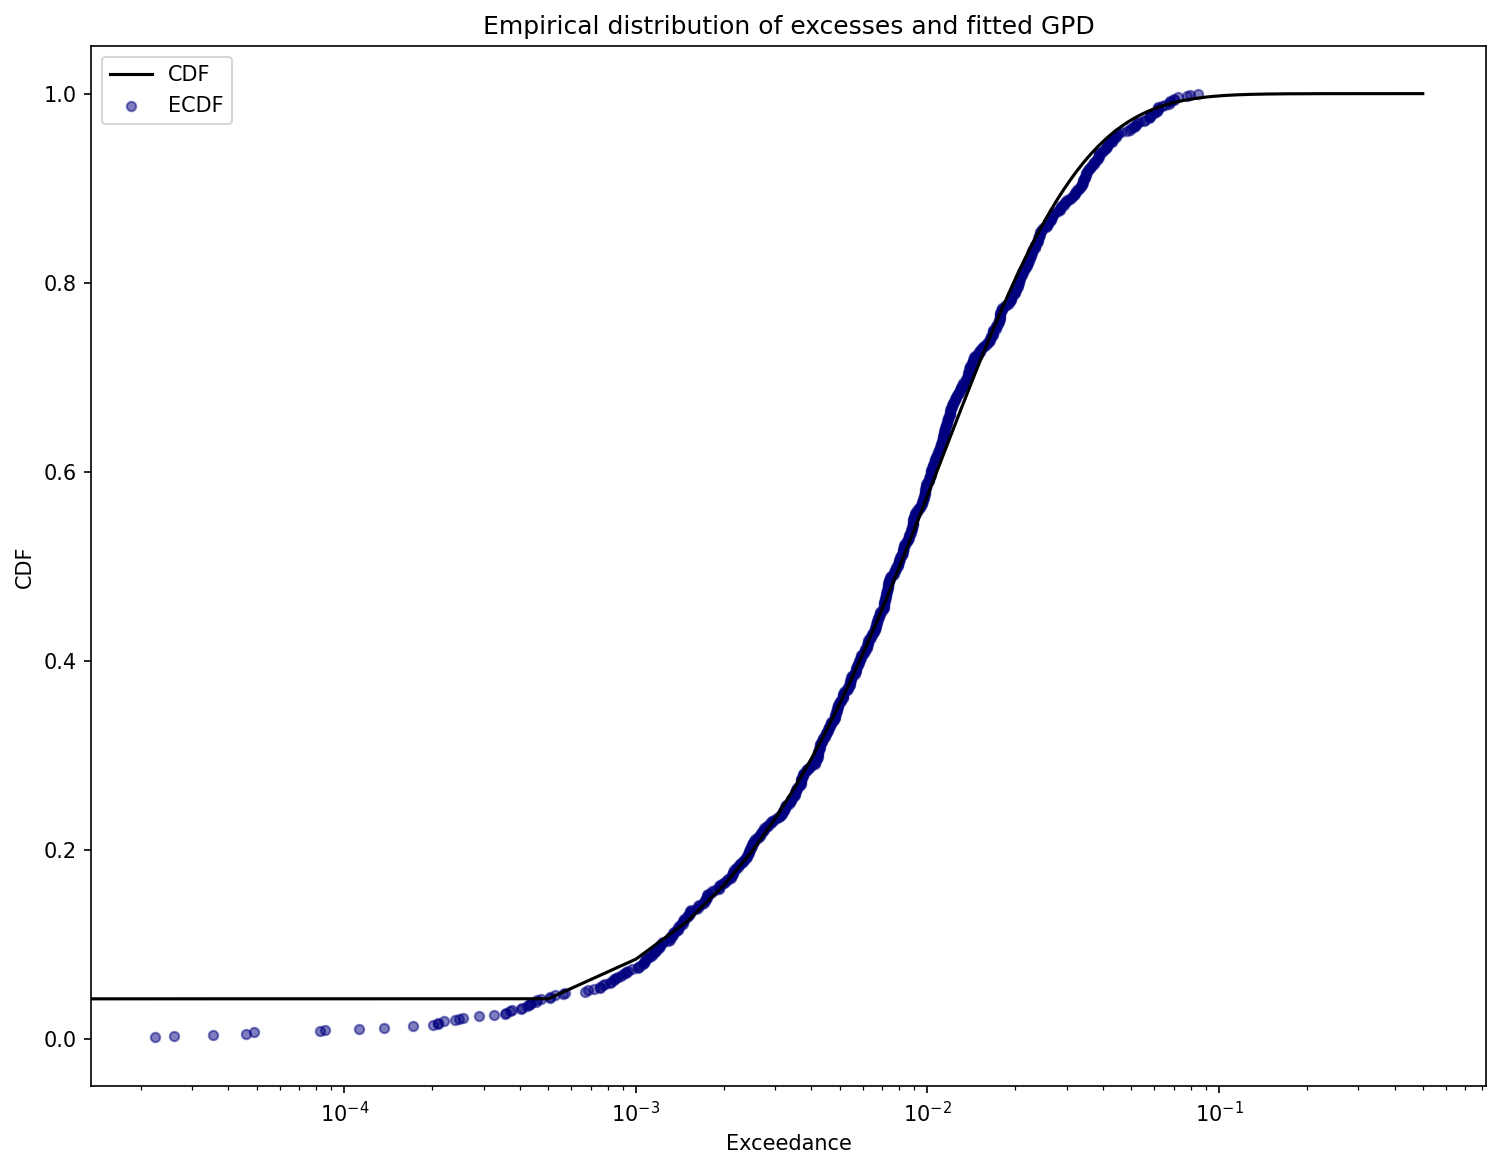

c: 0.1252989203203213
loc: 2.2323862659415266e-05
scale: 0.011063390185451374
Num: 764


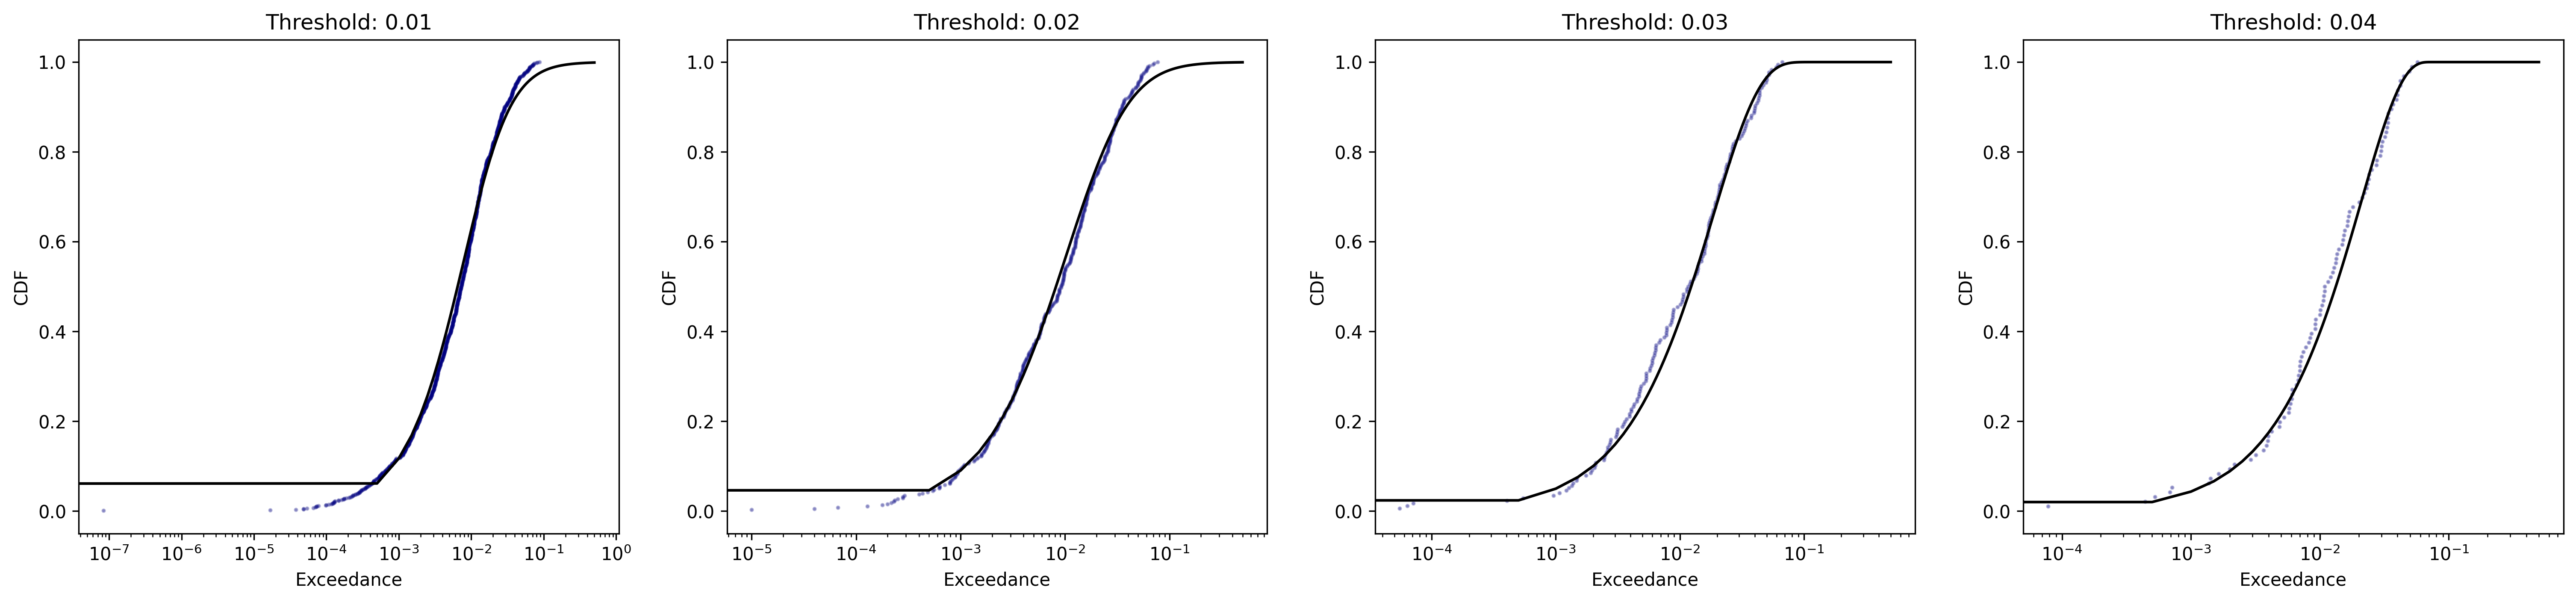

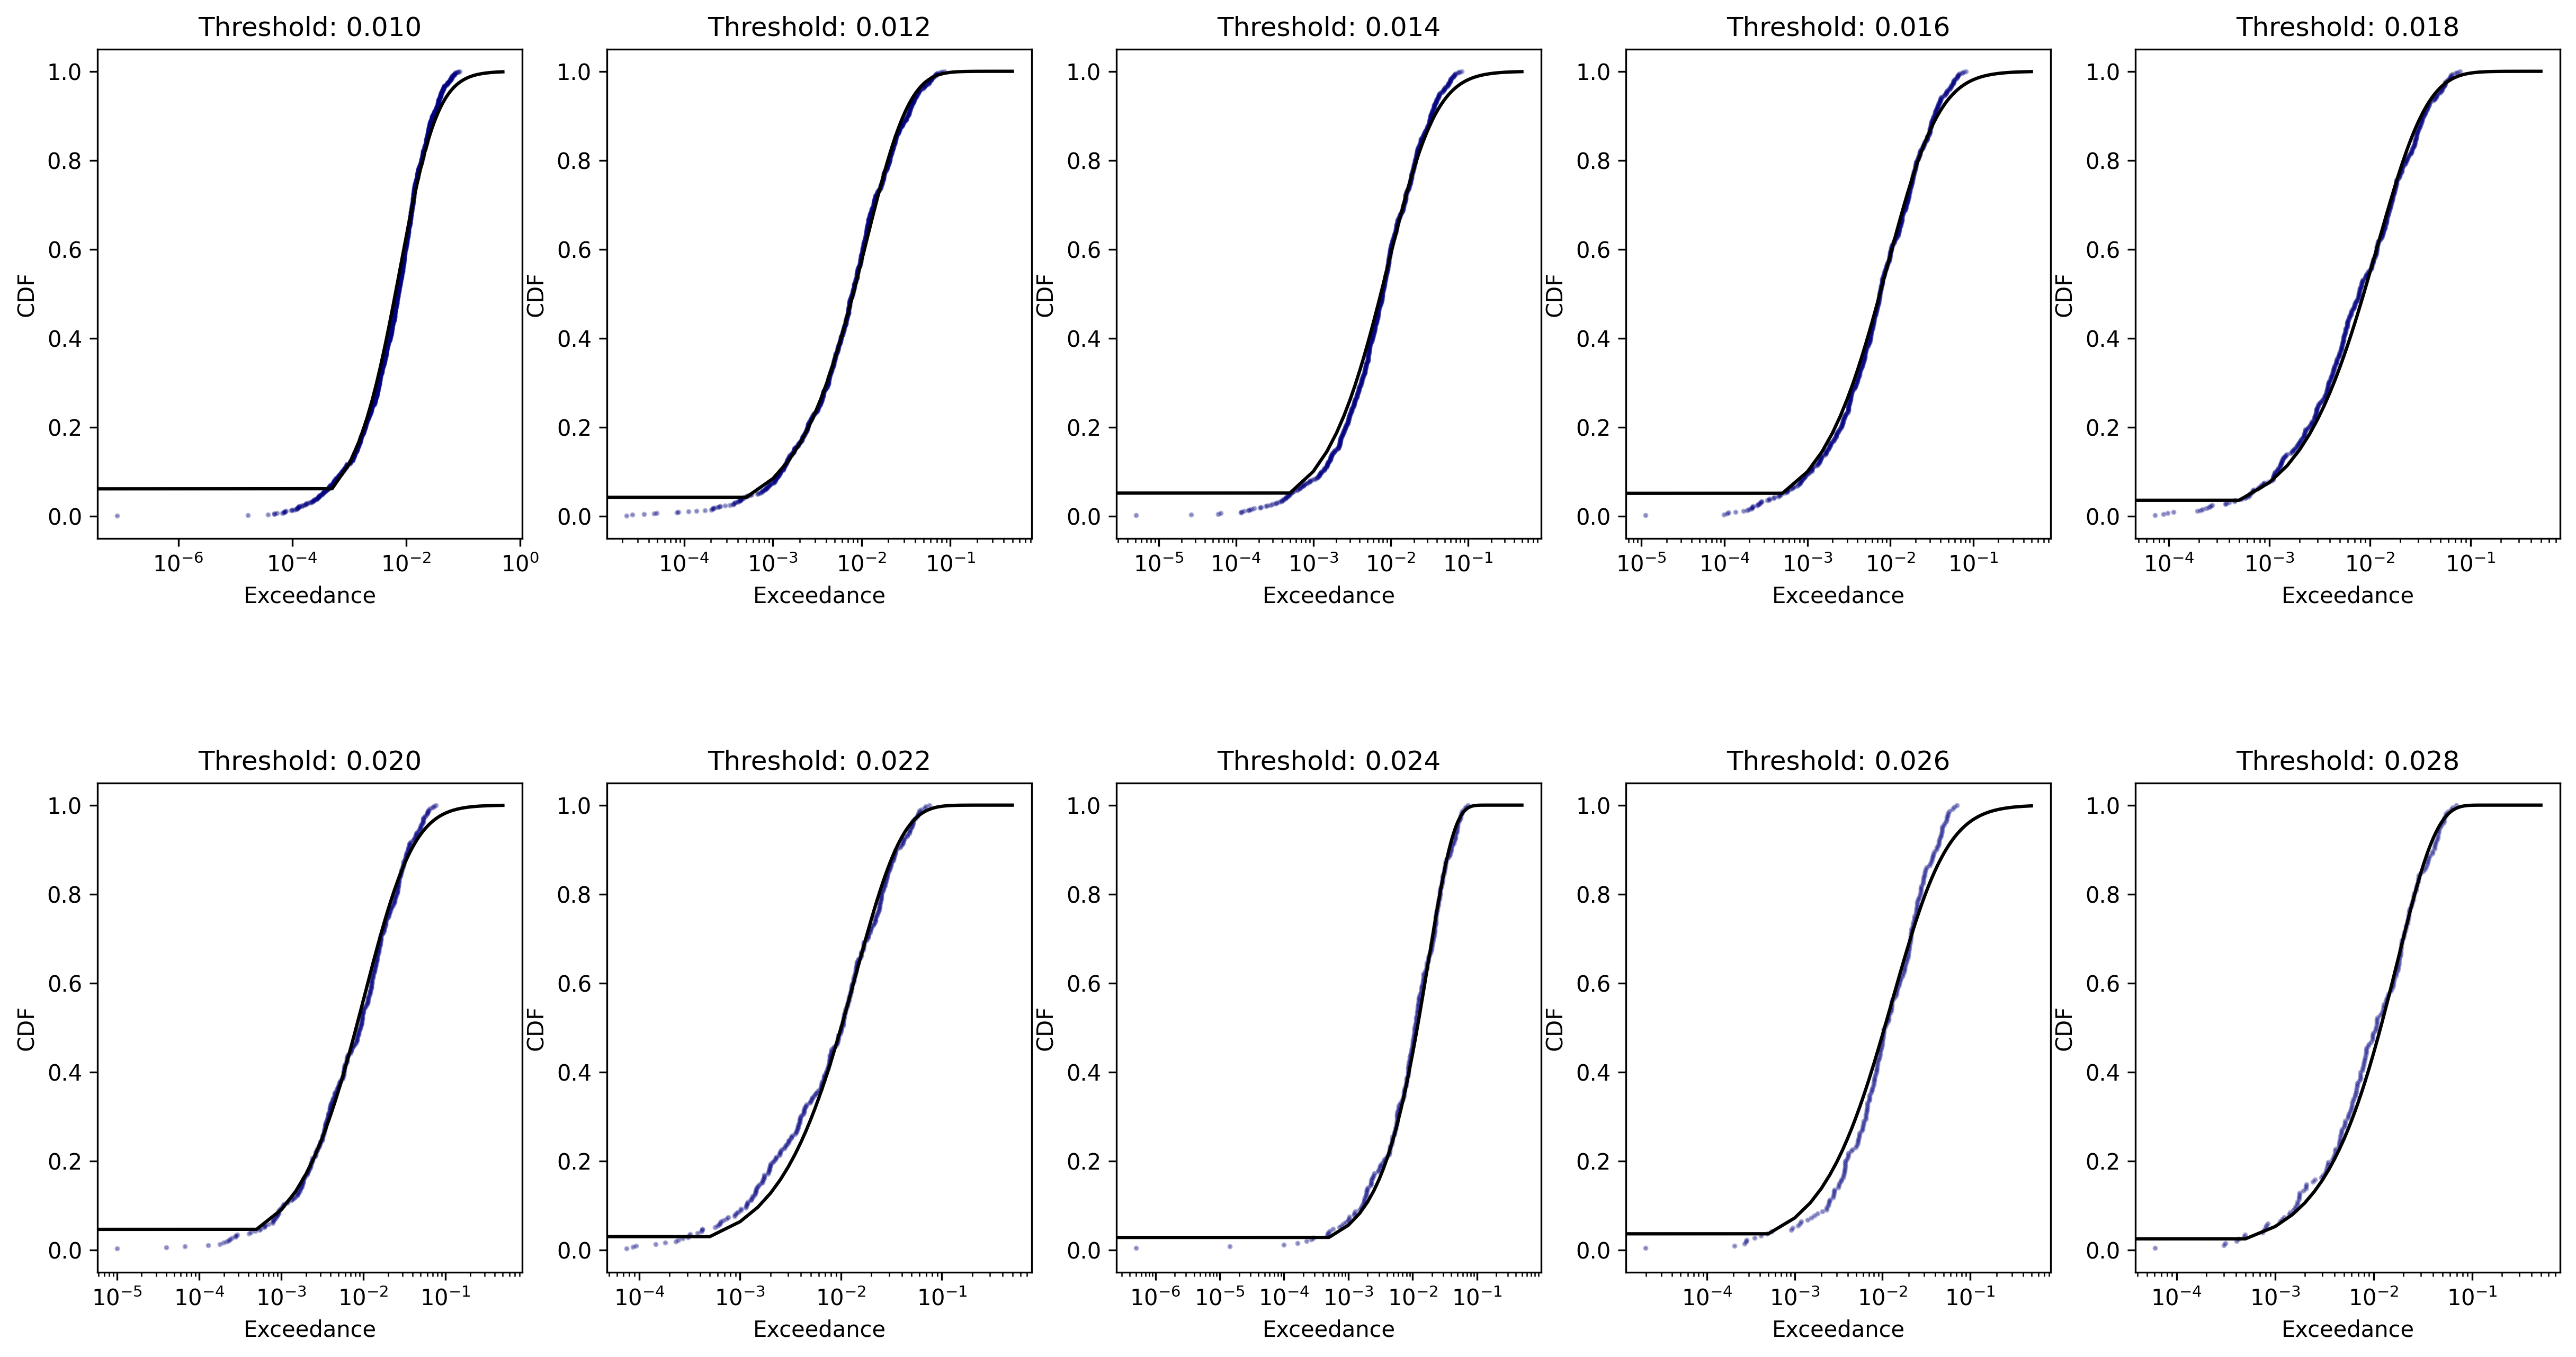

In [124]:
plot_figC(loss_hs300, 0.012)

# subplots for thresholds from 0.01 to 0.08
fig, axs = plt.subplots(1, 4, figsize=(25, 5), dpi=300)
# log scale X axis
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.04, 4), axs.flatten()):
    exceedances = loss_hs300[loss_hs300 > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.2f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

fig, axs = plt.subplots(2, 5, figsize=(20, 10), dpi=300)
fig.subplots_adjust(hspace=0.5)
for threshold, ax in zip(np.linspace(0.01, 0.028, 10), axs.flatten()):
    exceedances = loss_hs300[loss_hs300 > threshold] - threshold
    params = genpareto.fit(exceedances)
    c, loc, scale = params
    x = np.linspace(0, 0.5, 1000)
    y = genpareto.cdf(x, c, loc, scale)
    ax.plot(x, y, label='CDF', color='black')
    ecdf = ECDF(exceedances)
    ax.scatter(ecdf.x, ecdf.y, marker='o', alpha=0.3, label='ECDF', color='navy', s=2)
    ax.set_title('Threshold: %.3f' % threshold)
    ax.set_ylabel('CDF')
    ax.set_xlabel('Exceedance')
    ax.set_xscale('log')

### Hill

Hill_loss:, 0.0498


C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\4172889080.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\4172889080.py:5: RuntimeWarning: divide by zero encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\4172889080.py:5: RuntimeWarning: invalid value encountered in log
  alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
C:\Users\stansfield\AppData\Local\Temp\ipykernel_34624\4172889080.py:29: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for k in tqdm_notebook(ks):


  0%|          | 0/1000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Hill Estimator of Alpha')

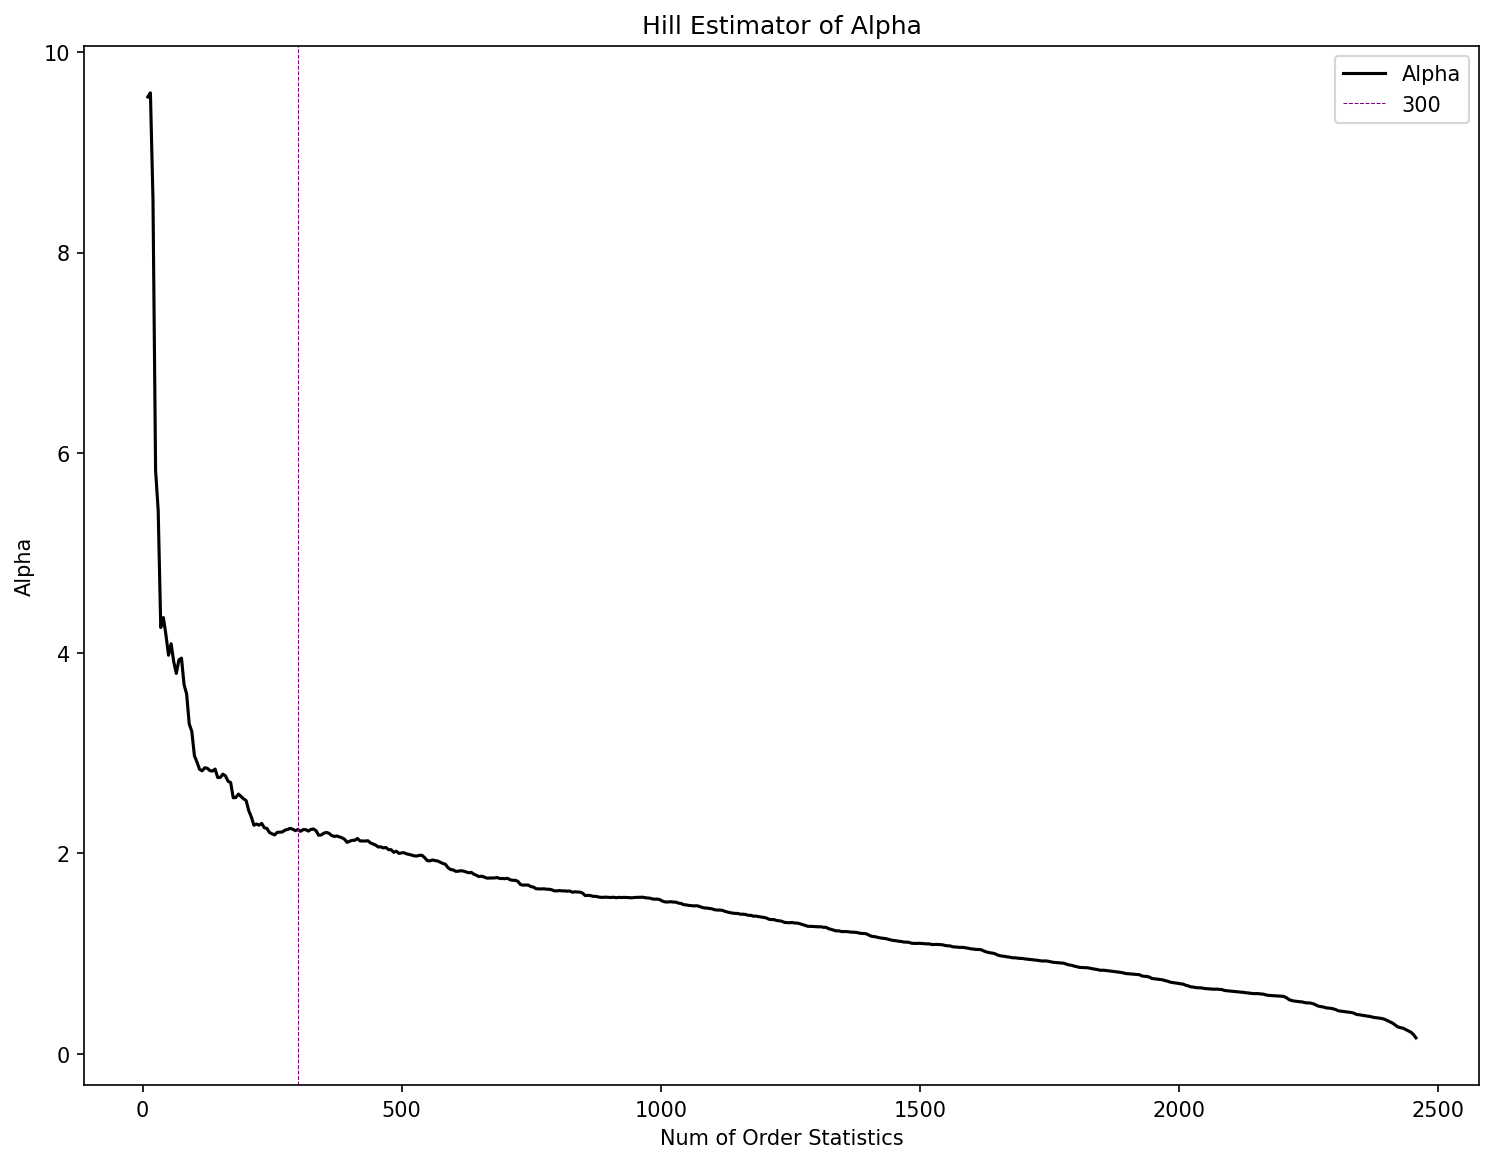

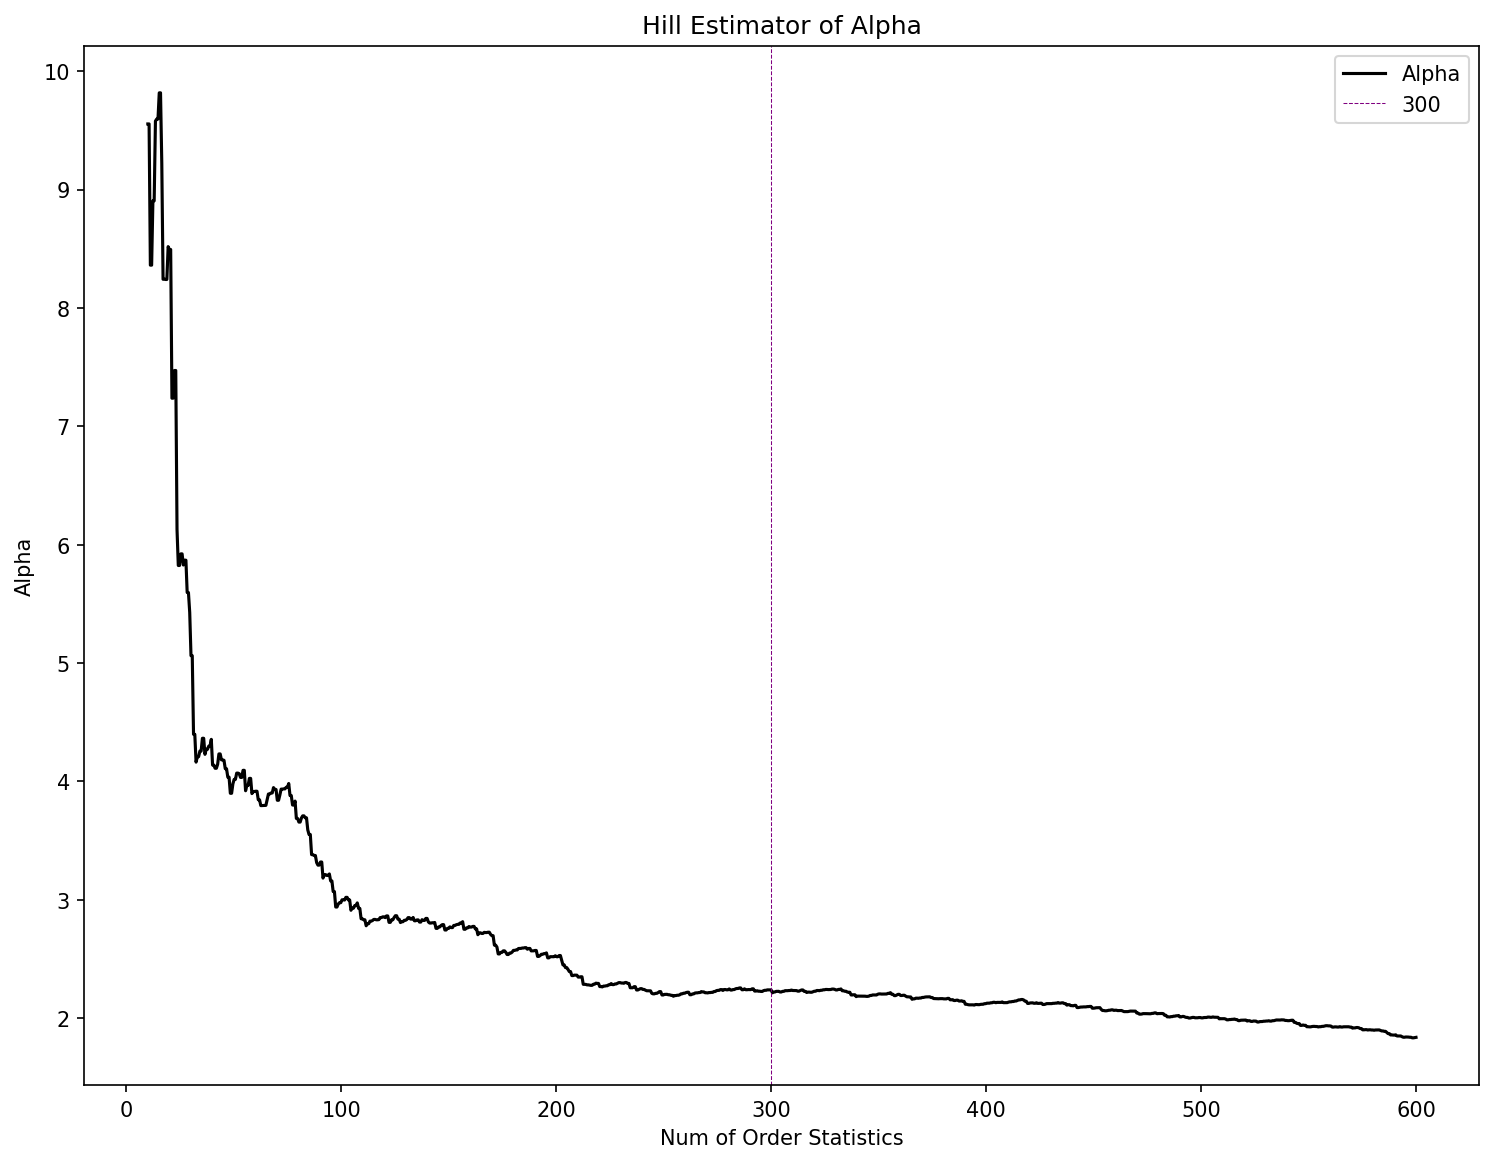

In [126]:
def q_hill(data, quantile=0.99, k=500):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]
    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))
    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha

print(f'Hill_loss:, {q_hill(loss_hs300, k=300)[0]:.4f}')

alphas = []
ks = np.linspace(10, 5000, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(loss_hs300, quantile=0.99, k=int(k))
    alphas.append(alpha)
plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')
plt.axvline(300, color='purple', linestyle='--', label='300', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

alphas = []
ks = np.linspace(10, 600, 1000)
qs = []
for k in tqdm_notebook(ks):
    q, alpha = q_hill(loss_hs300, quantile=0.99, k=int(k))
    alphas.append(alpha)
plt.figure(figsize=(12, 9), dpi=150)
plt.plot(ks, alphas, label='Alpha', color='black')
plt.axvline(300, color='purple', linestyle='--', label='300', linewidth=0.5)
plt.legend()
plt.xlabel('Num of Order Statistics')
plt.ylabel('Alpha')
plt.title('Hill Estimator of Alpha')

### Big Plot

Gaussian_loss: 0.0370
Empirical_loss: 0.0506
POT_loss: 0.0475
Hill_loss: 0.0498


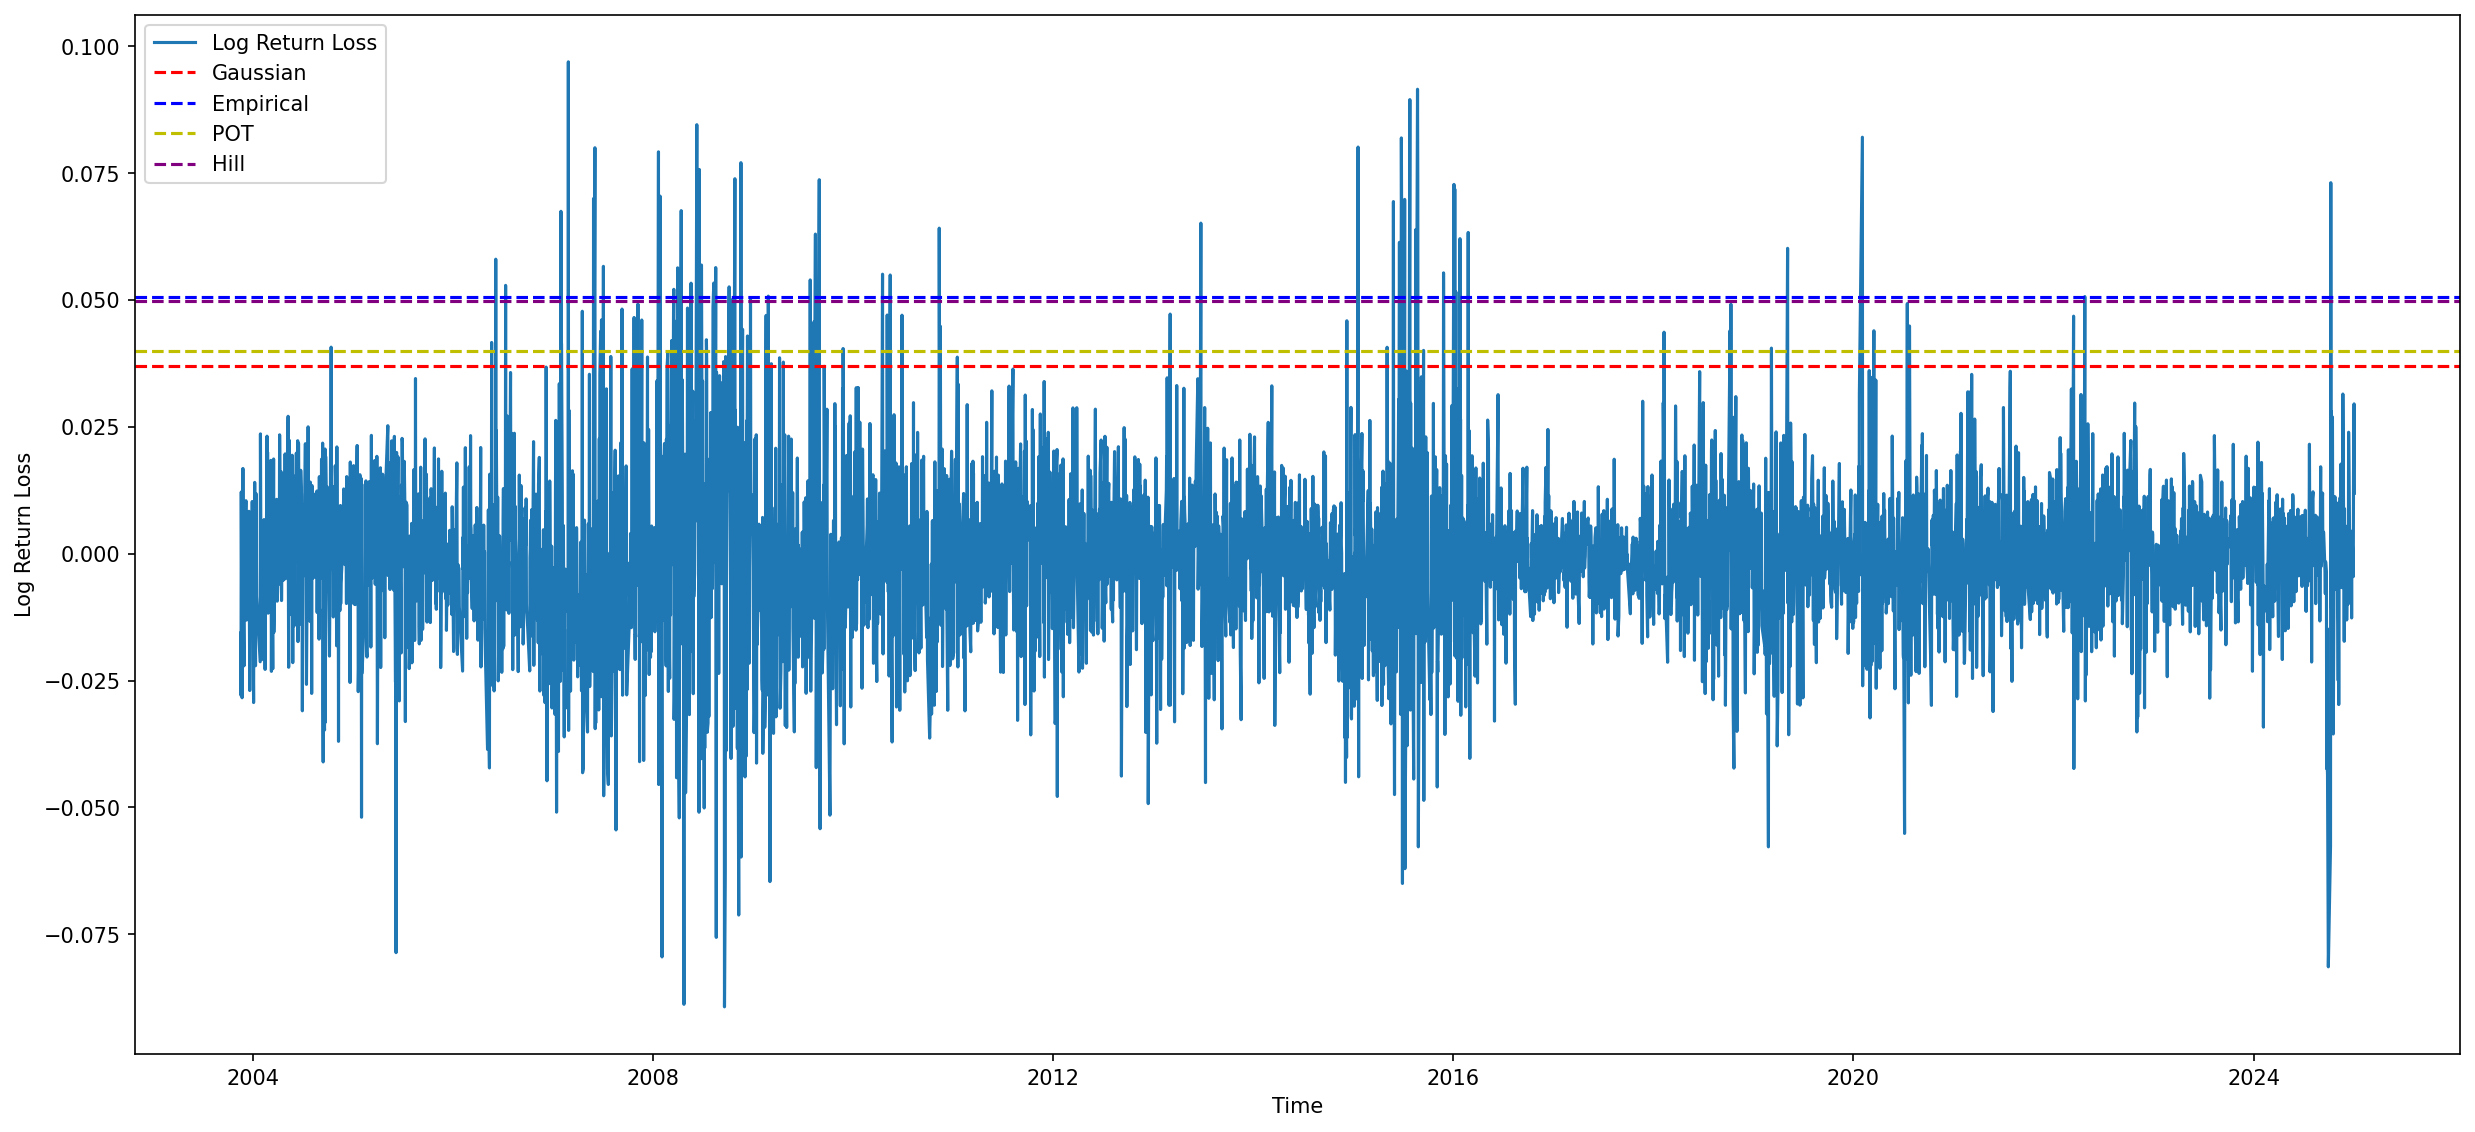

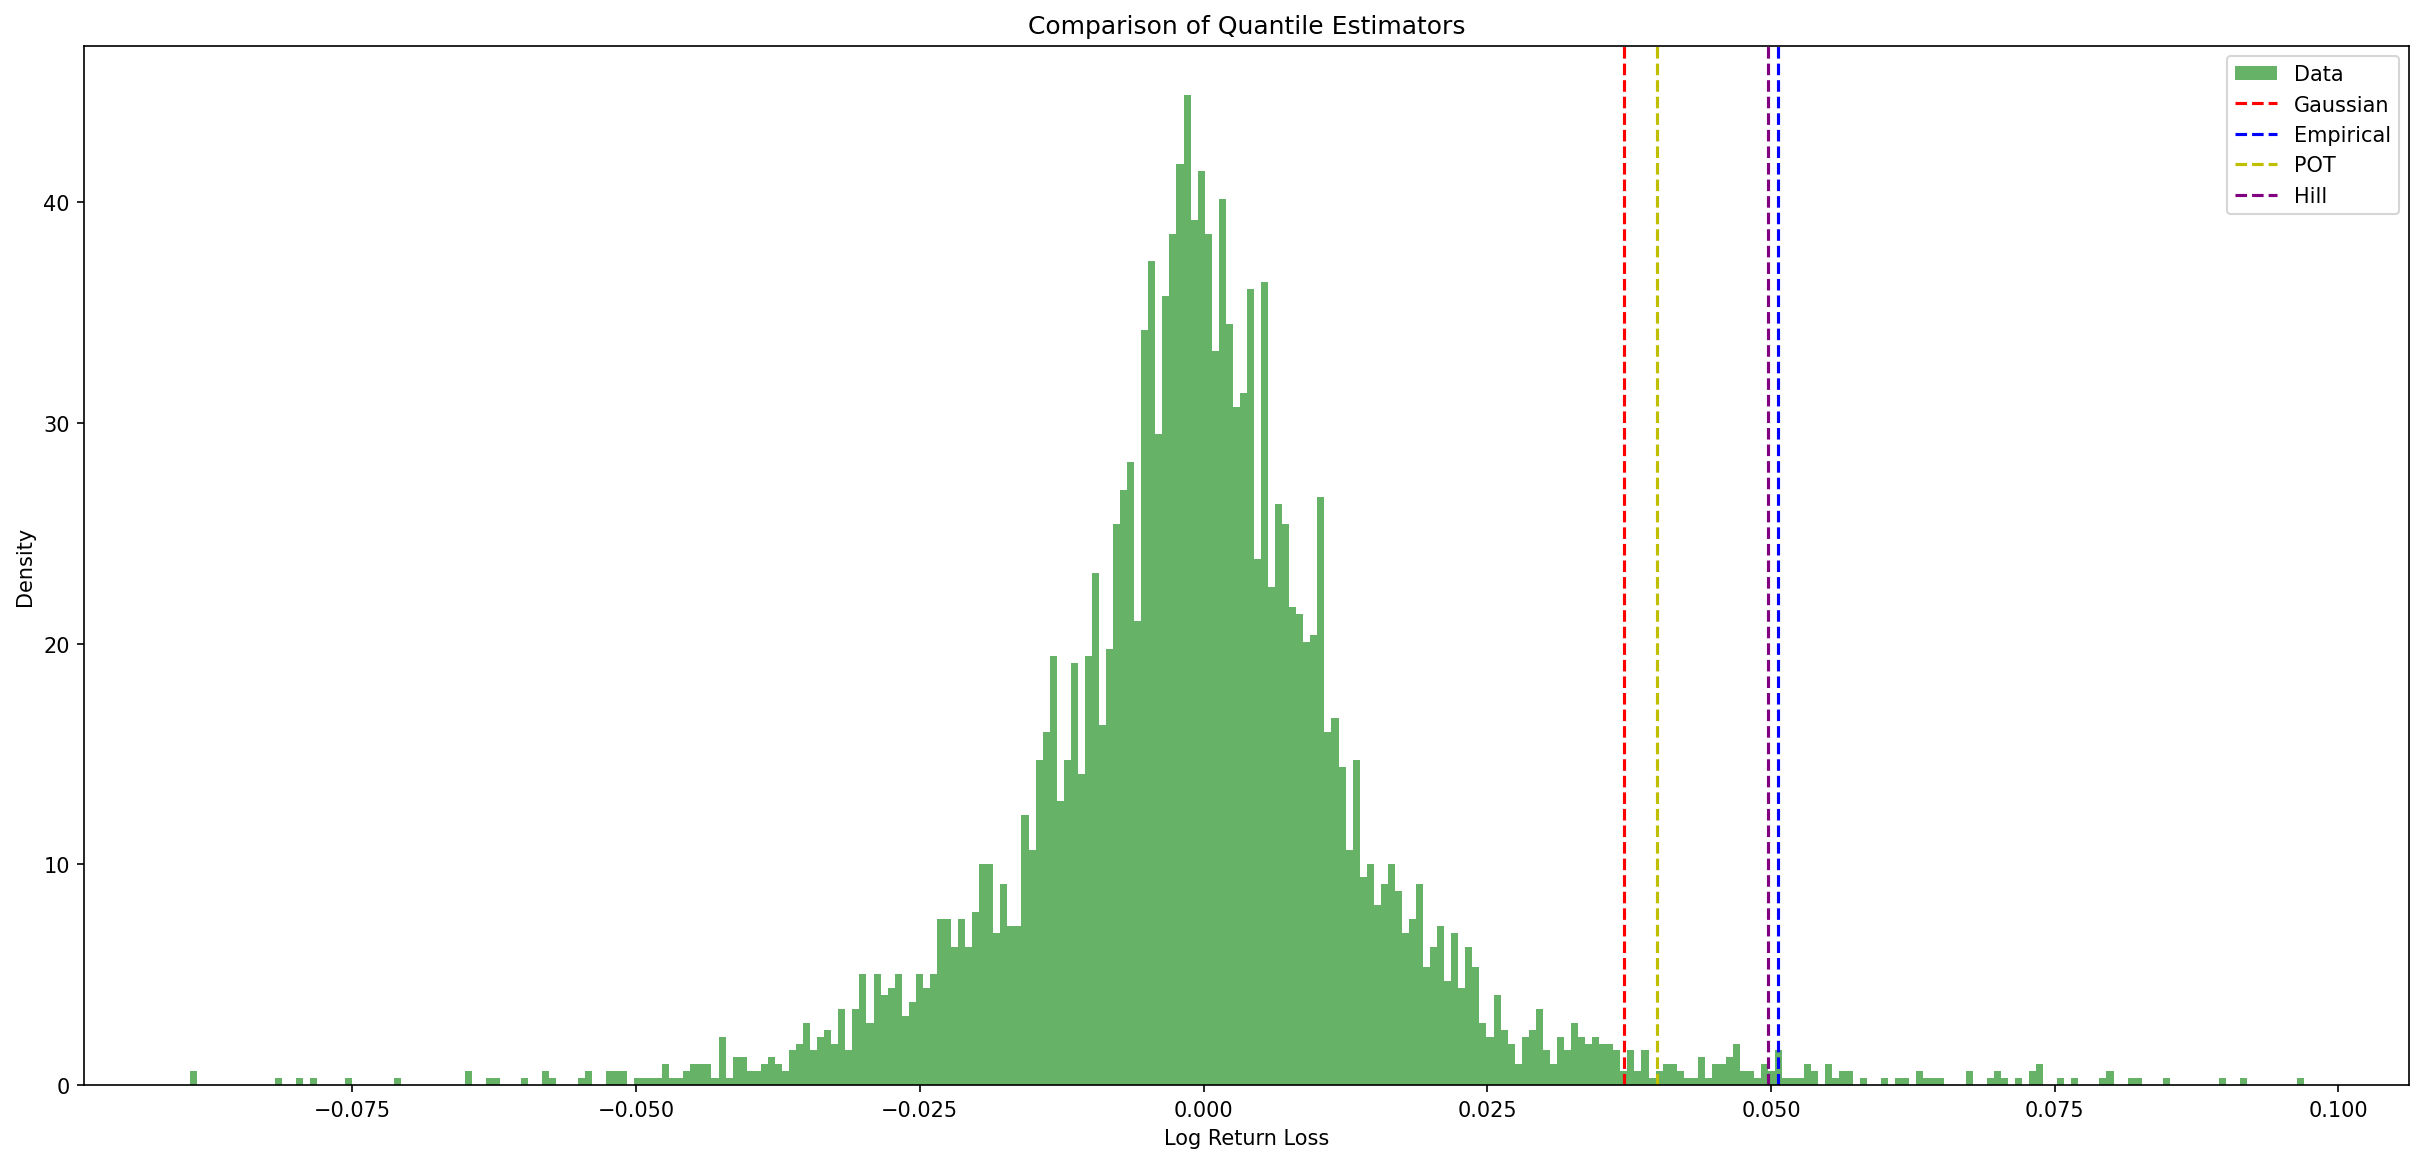

In [135]:
def q_gaussian(data, alpha=0.99):
    mean = np.mean(data)
    std = np.std(data)
    return stats.norm.ppf(alpha, loc=mean, scale=std)


def q_empirical(data, alpha=0.99):
    return np.quantile(data, alpha)


def q_pot(data, alpha=0.99, threshold=0.03):
    exceedances = data[data > threshold] - threshold
    if len(exceedances) == 0:
        q_pot = threshold
    else:
        # 拟合广义帕累托分布
        params = genpareto.fit(exceedances)
        c, loc, scale = params
        T = len(data)
        N = len(exceedances)
        # 计算0.99分位数
        q_pot = threshold + scale / c * ((len(data) / len(exceedances) * (1 - alpha)) ** (-c) - 1)
    return q_pot


def q_hill(data, quantile=0.99, k=650):
    sorted_data = np.sort(data)[::-1]
    top_k = sorted_data[:k]

    # 计算尾部指数
    alpha = 1 / np.mean(np.log(top_k / sorted_data[k]))

    # 计算0.99分位数
    q_hill = sorted_data[k] * ((len(data) / k) * (1 - quantile)) ** (-1 / alpha)
    return q_hill, alpha


data = loss_hs300
pot_threshold = 0.012
hill_k = 300
print(f'Gaussian_loss: {q_gaussian(data):.4f}')
print(f'Empirical_loss: {q_empirical(data):.4f}')
print(f'POT_loss: {q_pot(data, threshold=pot_threshold):.4f}')
print(f'Hill_loss: {q_hill(data, k=hill_k)[0]:.4f}')

plt.figure(figsize=(20, 9), dpi=150)
plt.plot(logreturn_hs300.index, data, label='Log Return Loss')
plt.axhline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axhline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axhline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axhline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Log Return Loss')

plt.figure(figsize=(20, 9), dpi=150)
plt.hist(data, bins=300, density=True, alpha=0.6, color='g', label='Data')
plt.axvline(q_gaussian(data), color='r', linestyle='--', label='Gaussian')
plt.axvline(q_empirical(data), color='b', linestyle='--', label='Empirical')
plt.axvline(q_pot(loss, alpha=0.99, threshold=pot_threshold), color='y', linestyle='--', label='POT')
plt.axvline(q_hill(data, k=hill_k)[0], color='purple', linestyle='--', label='Hill')
plt.legend()
plt.title("Comparison of Quantile Estimators")
plt.xlabel('Log Return Loss')
plt.ylabel('Density')
plt.show()